### Setup: Imports and constants
Imports the scientific stack and defines physical constants used throughout the notebook.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from itertools import combinations
from scipy.ndimage import gaussian_filter1d
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib.cm import RdYlGn

# Physical constants
kB_kJ = 8.314e-3       # kJ/(mol·K)
kB_K  = 1.0            # in reduced units (ε/kB)
N_A   = 6.022e23

### Build pentane geometry
Defines rotation helpers and builds pentane coordinates from bond length, angle, and dihedrals, then runs geometry sanity checks.

In [9]:
# ─────────────────────────────────────────────
# Cell 3 — Task 1: Initial Configuration
# ─────────────────────────────────────────────

def rotation_matrix(axis, angle_rad):
    """
    Rodrigues' rotation formula.
    Returns 3x3 rotation matrix that rotates by angle_rad around `axis`.
    """
    axis = axis / np.linalg.norm(axis)
    ux, uy, uz = axis
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    t = 1 - c
    return np.array([
        [t*ux*ux + c,    t*ux*uy - s*uz, t*ux*uz + s*uy],
        [t*ux*uy + s*uz, t*uy*uy + c,    t*uy*uz - s*ux],
        [t*ux*uz - s*uy, t*uy*uz + s*ux, t*uz*uz + c   ]
    ])

def place_next_atom(p_prev2, p_prev1, p_prev0, bond_len, bond_angle_rad, dihedral_rad):
    """
    p_prev0: atom i-3 — defines the dihedral reference plane (the ACTUAL upstream atom)
    p_prev2: atom i-2
    p_prev1: atom i-1 (atom we bond from)
    """
    b_axis     = p_prev1 - p_prev2
    b_axis_hat = b_axis / np.linalg.norm(b_axis)

    # Reference direction: project (p_prev0 - p_prev2) perpendicular to bond axis
    v_ref      = p_prev0 - p_prev2
    v_ref_perp = v_ref - np.dot(v_ref, b_axis_hat) * b_axis_hat
    v_ref_perp = v_ref_perp / np.linalg.norm(v_ref_perp)

    # Build bond direction at the correct bond angle, in the reference plane
    theta        = np.pi - bond_angle_rad
    bond_dir_ref = np.cos(theta) * b_axis_hat + np.sin(theta) * v_ref_perp

    # Rotate by the requested dihedral around the bond axis
    bond_dir = rotation_matrix(b_axis_hat, -dihedral_rad) @ bond_dir_ref
    return p_prev1 + bond_len * bond_dir


def build_pentane(phi1=180.0, phi2=180.0):
    r0, theta0 = 1.54, np.radians(114.0)
    pos = np.zeros((5, 3))
    pos[1] = [r0, 0.0, 0.0]
    bend = np.pi - theta0
    pos[2] = pos[1] + r0 * np.array([np.cos(bend), np.sin(bend), 0.0])

    # p_prev0=C0, p_prev2=C1, p_prev1=C2 → controls dihedral C0-C1-C2-C3 = phi2
    pos[3] = place_next_atom(pos[1], pos[2], pos[0], r0, theta0, np.radians(phi2))

    # p_prev0=C1, p_prev2=C2, p_prev1=C3 → controls dihedral C1-C2-C3-C4 = phi1
    pos[4] = place_next_atom(pos[2], pos[3], pos[1], r0, theta0, np.radians(phi1))

    return pos


# ── Quick sanity checks ───────────────────────────────────────────────────

def compute_dihedral(p0, p1, p2, p3):
    """Returns dihedral angle in degrees for the sequence p0-p1-p2-p3."""
    b1 = p1 - p0
    b2 = p2 - p1
    b3 = p3 - p2
    n1 = np.cross(b1, b2)
    n2 = np.cross(b2, b3)
    m1 = np.cross(n1, b2 / np.linalg.norm(b2))
    x  = np.dot(n1, n2)
    y  = np.dot(m1, n2)
    return np.degrees(np.arctan2(y, x))

def verify_geometry(positions, label=""):
    r0_chk    = 1.54
    theta0_chk = 114.0
    print(f"\n{'─'*45}")
    print(f"Geometry check: {label}")
    print(f"{'─'*45}")
    for i in range(4):
        d = np.linalg.norm(positions[i+1] - positions[i])
        print(f"  Bond C{i}-C{i+1}  : {d:.4f} Å  (target {r0_chk})")
    for i in range(3):
        v1 = positions[i]   - positions[i+1]
        v2 = positions[i+2] - positions[i+1]
        cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        ang = np.degrees(np.arccos(np.clip(cos_a, -1, 1)))
        print(f"  Angle C{i}-C{i+1}-C{i+2}: {ang:.2f}°  (target {theta0_chk}°)")
    d1 = compute_dihedral(positions[0], positions[1], positions[2], positions[3])
    d2 = compute_dihedral(positions[1], positions[2], positions[3], positions[4])
    print(f"  Dihedral C0-C1-C2-C3 : {d1:.2f}°")
    print(f"  Dihedral C1-C2-C3-C4 : {d2:.2f}°  ← project dihedral (atoms 1-2-3-4)")


# Test 1: all-trans (anti) conformation — both dihedrals = 180°
pos_trans = build_pentane(phi1=180.0, phi2=180.0)
verify_geometry(pos_trans, label="all-trans (phi1=180, phi2=180)")

# Test 2: gauche+ conformation — phi1 = 60°
pos_gauche = build_pentane(phi1=60.0, phi2=180.0)
verify_geometry(pos_gauche, label="gauche+ (phi1=60, phi2=180)")

# Test 3: gauche- conformation — phi1 = -60°
pos_gauchm = build_pentane(phi1=-60.0, phi2=180.0)
verify_geometry(pos_gauchm, label="gauche- (phi1=-60, phi2=180)")

# Default starting config for simulations: all-trans
initial_positions = build_pentane(phi1=180.0, phi2=180.0)
print(f"\nInitial positions (Å):\n{initial_positions}")


─────────────────────────────────────────────
Geometry check: all-trans (phi1=180, phi2=180)
─────────────────────────────────────────────
  Bond C0-C1  : 1.5400 Å  (target 1.54)
  Bond C1-C2  : 1.5400 Å  (target 1.54)
  Bond C2-C3  : 1.5400 Å  (target 1.54)
  Bond C3-C4  : 1.5400 Å  (target 1.54)
  Angle C0-C1-C2: 114.00°  (target 114.0°)
  Angle C1-C2-C3: 114.00°  (target 114.0°)
  Angle C2-C3-C4: 114.00°  (target 114.0°)
  Dihedral C0-C1-C2-C3 : 180.00°
  Dihedral C1-C2-C3-C4 : 180.00°  ← project dihedral (atoms 1-2-3-4)

─────────────────────────────────────────────
Geometry check: gauche+ (phi1=60, phi2=180)
─────────────────────────────────────────────
  Bond C0-C1  : 1.5400 Å  (target 1.54)
  Bond C1-C2  : 1.5400 Å  (target 1.54)
  Bond C2-C3  : 1.5400 Å  (target 1.54)
  Bond C3-C4  : 1.5400 Å  (target 1.54)
  Angle C0-C1-C2: 114.00°  (target 114.0°)
  Angle C1-C2-C3: 114.00°  (target 114.0°)
  Angle C2-C3-C4: 114.00°  (target 114.0°)
  Dihedral C0-C1-C2-C3 : 180.00°
  Dihedral

### Energy model functions
Implements TraPPE-UA energy terms (bond, angle, torsion, LJ) and scans the torsion and total energy landscapes.

In [10]:
# ── Constants ─────────────────────────────────────────────────────────────────
kB_kJ = 8.314e-3   # kJ/(mol·K)

# ── TraPPE-UA Parameters ─────────────────────────────────────────────────────-

# Lennard-Jones: (epsilon in kJ/mol, sigma in Å)
# Martin & Siepmann, JPCB 1998
LJ = {
    'CH3': {'eps': 98.0  * kB_kJ, 'sig': 3.75},   # terminal
    'CH2': {'eps': 46.0  * kB_kJ, 'sig': 3.95},   # internal
}

# Atom types for n-pentane UA sites: CH3-CH2-CH2-CH2-CH3
ATOM_TYPES = ['CH3', 'CH2', 'CH2', 'CH2', 'CH3']

# Bond: harmonic  V = (k_bond/2) * (r - r0)^2
# k_bond from project PDF Table 1
K_BOND = 452900.0   # kJ/mol/Å²
R0_CC    = 1.54       # Å

# Angle: harmonic  V = (k_angle/2) * (theta - theta0)^2
# 62.5 kcal/mol/rad² = 261.5 kJ/mol/rad² ... TraPPE uses 519.65 kJ/mol/rad²
K_ANGLE = 519.65    # kJ/mol/rad²   (= 124.2 kcal/mol/rad²)
THETA0  = np.radians(114.0)

# Torsion: Fourier form (IUPAC dihedral, trans = ±180°)
# Coefficients in units of kJ/mol
C0_TORS =   0.0   * kB_kJ
C1_TORS = 355.03  * kB_kJ
C2_TORS = -68.19  * kB_kJ
C3_TORS = 791.32  * kB_kJ

# Bonded connectivity for n-pentane (0-indexed)
BONDS   = [(0,1), (1,2), (2,3), (3,4)]
ANGLES  = [(0,1,2), (1,2,3), (2,3,4)]
TORSIONS = [(0,1,2,3), (1,2,3,4)]
UNIT_FACTOR = 100

# Non-bonded pairs: exclude 1-2 and 1-3; include 1-4 and beyond
# For 5-atom chain: only non-bonded pair is (0,4)  — the 1-5 pair
# 1-4 pairs: (0,3) and (1,4)
# Full non-bonded list (1-4 + 1-5):
NONBONDED_PAIRS = [(0, 4)]   # (0,4) is 1-5

# Vectorized index/parameter arrays
BOND_IDX      = np.array(BONDS, dtype=int)
ANGLE_IDX     = np.array(ANGLES, dtype=int)
TORSION_IDX   = np.array(TORSIONS, dtype=int)
NONBONDED_IDX = np.array(NONBONDED_PAIRS, dtype=int)
ATOM_EPS      = np.array([LJ[t]['eps'] for t in ATOM_TYPES])
ATOM_SIG      = np.array([LJ[t]['sig'] for t in ATOM_TYPES])


Conformation: Trans(180°)
  Bond energy   :     0.0000 kJ/mol
  Angle energy  :     0.0000 kJ/mol
  Torsion energy:     0.0000 kJ/mol
  LJ energy     :    -0.4070 kJ/mol
  Total energy  :    -0.4070 kJ/mol

Conformation: Gauche+(60°)
  Bond energy   :     0.0000 kJ/mol
  Angle energy  :     0.0000 kJ/mol
  Torsion energy:     3.5772 kJ/mol
  LJ energy     :    -0.6986 kJ/mol
  Total energy  :     2.8786 kJ/mol

Conformation: Eclipsed(0°)
  Bond energy   :     0.0000 kJ/mol
  Angle energy  :     0.0000 kJ/mol
  Torsion energy:    19.0615 kJ/mol
  LJ energy     :    -0.7941 kJ/mol
  Total energy  :    18.2674 kJ/mol


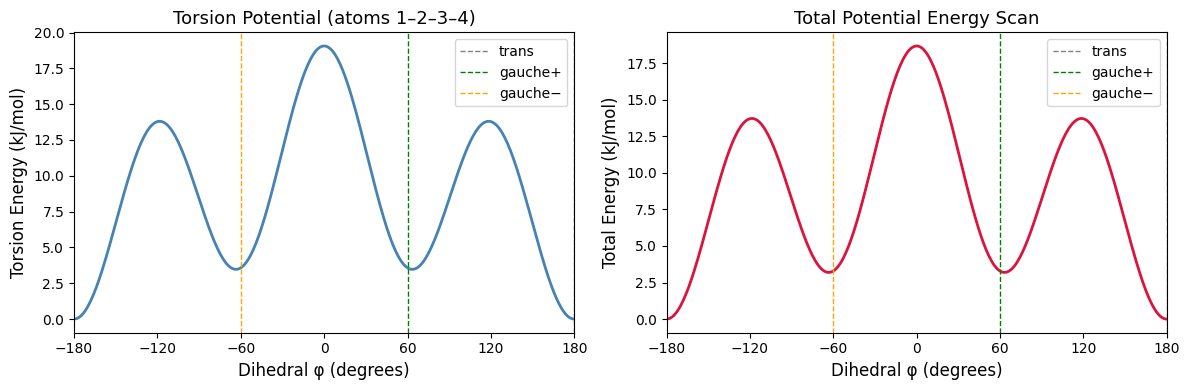


Saved: plots/torsion_energy_scan.png


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 4 — Force Field Energy Functions (TraPPE-UA)
# ─────────────────────────────────────────────────────────────────────────────


# ── Helper: dihedral angle ───────────────────────────────────────────────────-

def _dihedral_rad(p0, p1, p2, p3):
    """
    Returns dihedral angle in radians for the sequence p0-p1-p2-p3.
    Convention: trans = ±π, gauche± = ±π/3.
    Uses the atan2 formula for numerical stability.
    """
    b1 = p1 - p0
    b2 = p2 - p1
    b3 = p3 - p2
    n1 = np.cross(b1, b2)
    n2 = np.cross(b2, b3)
    b2_norm = b2 / np.linalg.norm(b2)
    m1 = np.cross(n1, b2_norm)
    x  = np.dot(n1, n2)
    y  = np.dot(m1, n2)
    return np.arctan2(y, x)


def _dihedral_rad_batch(p0, p1, p2, p3):
    """Vectorized dihedral angles for batched coordinates."""
    b1 = p1 - p0
    b2 = p2 - p1
    b3 = p3 - p2
    n1 = np.cross(b1, b2)
    n2 = np.cross(b2, b3)
    b2_norm = b2 / np.linalg.norm(b2, axis=2, keepdims=True)
    m1 = np.cross(n1, b2_norm)
    x  = np.sum(n1 * n2, axis=2)
    y  = np.sum(m1 * n2, axis=2)
    return np.arctan2(y, x)

# ── Helper: Lorentz-Berthelot mixing rules ─────────────────────────────────--

def _lj_mixed(type_i, type_j):
    """
    Returns (eps_ij, sig_ij) using Lorentz-Berthelot rules:
      sigma_ij   = (sigma_i + sigma_j) / 2
      epsilon_ij = sqrt(epsilon_i * epsilon_j)
    """
    ei = LJ[type_i]['eps'];  si = LJ[type_i]['sig']
    ej = LJ[type_j]['eps'];  sj = LJ[type_j]['sig']
    return np.sqrt(ei * ej), 0.5 * (si + sj)

# ── Energy components (vectorized core) ─────────────────────────────────------

def _bond_energy_batch(pos):
    r_vec = pos[:, BOND_IDX[:, 1]] - pos[:, BOND_IDX[:, 0]]
    r     = np.linalg.norm(r_vec, axis=2)
    return 0.5 * K_BOND * np.sum((r - R0_CC)**2, axis=1)


def _angle_energy_batch(pos):
    i, j, k = ANGLE_IDX[:, 0], ANGLE_IDX[:, 1], ANGLE_IDX[:, 2]
    v1 = pos[:, i] - pos[:, j]
    v2 = pos[:, k] - pos[:, j]
    cos_theta = np.sum(v1 * v2, axis=2) / (
        np.linalg.norm(v1, axis=2) * np.linalg.norm(v2, axis=2)
    )
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta)
    return 0.5 * K_ANGLE * np.sum((theta - THETA0)**2, axis=1)


def _torsion_energy_batch(pos):
    i, j, k, l = (TORSION_IDX[:, 0], TORSION_IDX[:, 1],
                  TORSION_IDX[:, 2], TORSION_IDX[:, 3])
    phi = _dihedral_rad_batch(pos[:, i], pos[:, j], pos[:, k], pos[:, l])
    term = (C0_TORS
            + C1_TORS * (1 + np.cos(phi))
            + C2_TORS * (1 - np.cos(2 * phi))
            + C3_TORS * (1 + np.cos(3 * phi)))
    return np.sum(term, axis=1)


def _lj_energy_batch(pos):
    i, j = NONBONDED_IDX[:, 0], NONBONDED_IDX[:, 1]
    eps_ij = np.sqrt(ATOM_EPS[i] * ATOM_EPS[j])
    sig_ij = 0.5 * (ATOM_SIG[i] + ATOM_SIG[j])
    r_vec = pos[:, j] - pos[:, i]
    r = np.linalg.norm(r_vec, axis=2)
    sr6 = (sig_ij / r)**6
    return np.sum(4.0 * eps_ij * (sr6**2 - sr6), axis=1)

# ── Energy components (public API) ─────────────────────────────────────────---

def bond_energy(positions):
    """
    Harmonic bond stretching:
      V_bond = (K_BOND / 2) * (r_ij - R0)^2
    Summed over all 4 bonds: (0-1), (1-2), (2-3), (3-4)
    Units: kJ/mol
    """
    pos = np.asarray(positions)
    if pos.ndim == 2:
        return float(_bond_energy_batch(pos[None, ...])[0])
    return _bond_energy_batch(pos)


def angle_energy(positions):
    """
    Harmonic angle bending:
      V_angle = (K_ANGLE / 2) * (theta_ijk - THETA0)^2
    Summed over all 3 angles: (0-1-2), (1-2-3), (2-3-4)
    Units: kJ/mol
    """
    pos = np.asarray(positions)
    if pos.ndim == 2:
        return float(_angle_energy_batch(pos[None, ...])[0])
    return _angle_energy_batch(pos)


def torsion_energy(positions):
    """
    Fourier torsion potential (IUPAC dihedral):
        V(phi) = C0 + C1(1 + cos(phi)) + C2(1 - cos(2phi)) + C3(1 + cos(3phi))

    Summed over both backbone dihedrals: (0-1-2-3) and (1-2-3-4).
    Units: kJ/mol
    """
    pos = np.asarray(positions)
    total = 0.0
    for (i, j, k, l) in TORSIONS:
        phi = _dihedral_rad(pos[i], pos[j], pos[k], pos[l])
        total += (C0_TORS
                  + C1_TORS * (1 + np.cos(phi))
                  + C2_TORS * (1 - np.cos(2 * phi))
                  + C3_TORS * (1 + np.cos(3 * phi)))
    return total


def lj_energy(positions):
    """
    Lennard-Jones non-bonded interactions:
      V_LJ = 4 * eps_ij * [ (sig_ij/r)^12 - (sig_ij/r)^6 ]

    Pairs included (TraPPE-UA convention for linear alkanes):
      - 1-4 pairs  : (0,3), (1,4)   → full LJ (no scaling)
      - 1-5 pair   : (0,4)          → full LJ

    Excluded pairs (1-2 and 1-3): no interaction.
    Mixing rules: Lorentz-Berthelot.
    Units: kJ/mol
    """
    pos = np.asarray(positions)
    if pos.ndim == 2:
        return float(_lj_energy_batch(pos[None, ...])[0])
    return _lj_energy_batch(pos)


def total_energy(positions):
    """
    Full TraPPE-UA potential energy of n-pentane:
      E_total = E_bond + E_angle + E_torsion + E_LJ
    Units: kJ/mol
    """
    pos = np.asarray(positions)
    if pos.ndim == 2:
        return float(_bond_energy_batch(pos[None, ...])[0]
                     + _angle_energy_batch(pos[None, ...])[0]
                     + _torsion_energy_batch(pos[None, ...])[0]
                     + _lj_energy_batch(pos[None, ...])[0])
    return (_bond_energy_batch(pos)
            + _angle_energy_batch(pos)
            + _torsion_energy_batch(pos)
            + _lj_energy_batch(pos))


def total_energy_batch(positions_batch):
    """Vectorized total energy for positions_batch with shape (N, 5, 3)."""
    pos = np.asarray(positions_batch)
    return (_bond_energy_batch(pos)
            + _angle_energy_batch(pos)
            + _torsion_energy_batch(pos)
            + _lj_energy_batch(pos))


# ── Sanity checks ─────────────────────────────────────────────────────────----

if __name__ == "__main__" or True:

    pos_trans  = build_pentane(phi1=180.0, phi2=180.0)
    pos_gauche = build_pentane(phi1= 60.0, phi2=180.0)
    pos_eclip  = build_pentane(phi1=  0.0, phi2=180.0)


    for label, pos in [("Trans(180°)", pos_trans),
                        ("Gauche+(60°)", pos_gauche),
                        ("Eclipsed(0°)", pos_eclip)]:
        Eb  = bond_energy(pos)
        Ea  = angle_energy(pos)
        Et  = torsion_energy(pos)
        Elj = lj_energy(pos)
        Etot = total_energy(pos)
        print(f"\nConformation: {label}")
        print(f"  Bond energy   : {Eb:10.4f} kJ/mol")
        print(f"  Angle energy  : {Ea:10.4f} kJ/mol")
        print(f"  Torsion energy: {Et:10.4f} kJ/mol")
        print(f"  LJ energy     : {Elj:10.4f} kJ/mol")
        print(f"  Total energy  : {Etot:10.4f} kJ/mol")

    # ── Plot torsion potential scan ─────────────────────────────────────---
    phi_vals = np.linspace(-180, 180, 361)
    E_tors_scan = []
    E_total_scan = []

    for phi in phi_vals:
        pos = build_pentane(phi1=phi, phi2=180.0)
        E_tors_scan.append(torsion_energy(pos))
        E_total_scan.append(total_energy(pos))

    # Shift so minimum = 0
    E_tors_arr  = np.array(E_tors_scan)  - min(E_tors_scan)
    E_total_arr = np.array(E_total_scan) - min(E_total_scan)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(phi_vals, E_tors_arr, color='steelblue', lw=2)
    axes[0].set_xlabel("Dihedral φ (degrees)", fontsize=12)
    axes[0].set_ylabel("Torsion Energy (kJ/mol)", fontsize=12)
    axes[0].set_title("Torsion Potential (atoms 1–2–3–4)", fontsize=13)
    axes[0].axvline( 180, color='gray', ls='--', lw=1, label='trans')
    axes[0].axvline(  60, color='green', ls='--', lw=1, label='gauche+')
    axes[0].axvline( -60, color='orange', ls='--', lw=1, label='gauche−')
    axes[0].legend(fontsize=10)
    axes[0].set_xlim(-180, 180)
    axes[0].set_xticks(np.arange(-180, 181, 60))

    axes[1].plot(phi_vals, E_total_arr, color='crimson', lw=2)
    axes[1].set_xlabel("Dihedral φ (degrees)", fontsize=12)
    axes[1].set_ylabel("Total Energy (kJ/mol)", fontsize=12)
    axes[1].set_title("Total Potential Energy Scan", fontsize=13)
    axes[1].axvline( 180, color='gray', ls='--', lw=1, label='trans')
    axes[1].axvline(  60, color='green', ls='--', lw=1, label='gauche+')
    axes[1].axvline( -60, color='orange', ls='--', lw=1, label='gauche−')
    axes[1].legend(fontsize=10)
    axes[1].set_xlim(-180, 180)
    axes[1].set_xticks(np.arange(-180, 181, 60))

    plt.tight_layout()
    plt.savefig("plots/torsion_energy_scan.png", dpi=150)
    plt.show()
    print("\nSaved: plots/torsion_energy_scan.png")

### Dihedral utilities
Adds dihedral calculators, validates them on test conformations, and plots round-trip accuracy.

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5 — Dihedral Calculation Utility
# ─────────────────────────────────────────────────────────────────────────────

def compute_dihedral(p0, p1, p2, p3):
    """
    Computes the dihedral (torsion) angle for the atom sequence p0-p1-p2-p3.

    Uses the atan2 formula via normal vectors for full [-180, 180] range
    and numerical stability near 0° and 180°.

    Convention  (IUPAC / standard MD):
        trans  =  180°  (or ±180°)
        gauche+ =  +60°
        gauche− =  -60°
        eclipsed =   0°

    Parameters
    ----------
    p0, p1, p2, p3 : array-like, shape (3,)
        Cartesian coordinates in any consistent unit (Å, nm, …)

    Returns
    -------
    angle_deg : float
        Dihedral angle in degrees, in the range (-180, 180].
    """
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    p3 = np.asarray(p3, dtype=float)

    # Bond vectors
    b1 = p1 - p0   # vector along bond 0→1
    b2 = p2 - p1   # vector along bond 1→2  (the central bond)
    b3 = p3 - p2   # vector along bond 2→3

    # Normal vectors to the two planes
    n1 = np.cross(b1, b2)   # normal to plane defined by b1, b2
    n2 = np.cross(b2, b3)   # normal to plane defined by b2, b3

    # Unit vector along the central bond
    b2_hat = b2 / np.linalg.norm(b2)

    # m1 completes a right-handed frame: (n1, m1, b2_hat)
    # It lies in the first plane but perpendicular to b2
    m1 = np.cross(n1, b2_hat)

    # atan2 gives the signed angle in the full [-π, π] range
    # x = cos(phi), y = sin(phi)
    x = np.dot(n1, n2)
    y = np.dot(m1, n2)

    angle_rad = np.arctan2(y, x)
    angle_deg = np.degrees(angle_rad)

    return angle_deg


def compute_all_dihedrals(positions):
    """
    Computes both backbone dihedrals of n-pentane.

    Returns
    -------
    phi_1234 : float
        Dihedral C1-C2-C3-C4 (atoms 1,2,3,4) — the PROJECT dihedral of interest.
    phi_0123 : float
        Dihedral C0-C1-C2-C3 (atoms 0,1,2,3) — the second backbone dihedral.
    """
    phi_1234 = compute_dihedral(positions[1], positions[2],
                                positions[3], positions[4])
    phi_0123 = compute_dihedral(positions[0], positions[1],
                                positions[2], positions[3])
    return phi_1234, phi_0123


# ── Sanity checks ─────────────────────────────────────────────────────────────

if __name__ == "__main__" or True:

    print("=" * 50)
    print("Dihedral sanity checks")
    print("=" * 50)

    # ── Test all canonical conformations ──────────────────────────────────
    test_cases = [
        ( 180.0,  180.0, "all-trans"),
        (  60.0,  180.0, "gauche+ / trans"),
        ( -60.0,  180.0, "gauche− / trans"),
        (  60.0,   60.0, "gauche+ / gauche+"),
        (   0.0,  180.0, "eclipsed / trans"),
        ( 120.0,  180.0, "barrier region"),
    ]

    print(f"\n{'Config':<26} {'phi1 set':>9} {'phi1 calc':>10} {'phi2 set':>9} {'phi2 calc':>10} {'match':>6}")
    print("-" * 75)

    all_pass = True
    for phi1_set, phi2_set, label in test_cases:
        pos = build_pentane(phi1=phi1_set, phi2=phi2_set)
        phi1_calc, phi2_calc = compute_all_dihedrals(pos)
        # Allow 0.1° tolerance for floating point
        match1 = abs(phi1_calc - phi1_set) < 0.1
        match2 = abs(phi2_calc - phi2_set) < 0.1
        ok = "✓" if (match1 and match2) else "✗"
        if not (match1 and match2):
            all_pass = False
        print(f"{label:<26} {phi1_set:>9.1f} {phi1_calc:>10.3f} "
              f"{phi2_set:>9.1f} {phi2_calc:>10.3f} {ok:>6}")

    print("-" * 75)
    print(f"All tests passed: {all_pass}")

Dihedral sanity checks

Config                      phi1 set  phi1 calc  phi2 set  phi2 calc  match
---------------------------------------------------------------------------
all-trans                      180.0    180.000     180.0    180.000      ✓
gauche+ / trans                 60.0     60.000     180.0    180.000      ✓
gauche− / trans                -60.0    -60.000     180.0    180.000      ✓
gauche+ / gauche+               60.0     60.000      60.0     60.000      ✓
eclipsed / trans                 0.0      0.000     180.0    180.000      ✓
barrier region                 120.0    120.000     180.0    180.000      ✓
---------------------------------------------------------------------------
All tests passed: True


### Monte Carlo sampling (NVT)
Runs Metropolis MC at 120 K and 250 K, records dihedrals and energies, and plots time series and histograms.

### Molecular dynamics sampling (NVT)
Implements velocity Verlet MD with velocity rescaling, runs both temperatures, and plots dihedrals, histograms, and temperature traces.

### MC vs MD comparison
Plots MC and MD side by side, summarizes crossings and conformations, and produces comparison figures.

### Umbrella sampling with WHAM
Runs umbrella-biased MC windows, combines them with WHAM to get the unbiased PMF, and plots window diagnostics and results.


  Umbrella Sampling at 120 K
  36 windows × 13888 steps  |  k_umb = 0.0800 kJ/mol/deg²
    Window  1/36  φ₀= -180.0°  mean_φ= -173.3°  acc=34.3%
    Window  9/36  φ₀= -100.0°  mean_φ=  -98.9°  acc=34.6%
    Window 18/36  φ₀=  -10.0°  mean_φ=  -11.6°  acc=34.1%
    Window 27/36  φ₀=   80.0°  mean_φ=   75.6°  acc=33.7%
    Window 36/36  φ₀=  170.0°  mean_φ=  172.2°  acc=33.9%
  Mean acceptance: 34.3%
  Running WHAM ...
    WHAM reached max iterations (5000)  (Δf = 3.30e-08)

  Umbrella Sampling at 250 K
  36 windows × 13888 steps  |  k_umb = 0.0800 kJ/mol/deg²
    Window  1/36  φ₀= -180.0°  mean_φ=  -87.0°  acc=48.1%
    Window  9/36  φ₀= -100.0°  mean_φ=  -98.7°  acc=48.0%
    Window 18/36  φ₀=  -10.0°  mean_φ=  -13.3°  acc=47.9%
    Window 27/36  φ₀=   80.0°  mean_φ=   79.1°  acc=47.9%
    Window 36/36  φ₀=  170.0°  mean_φ=  169.9°  acc=48.1%
  Mean acceptance: 48.1%
  Running WHAM ...
    WHAM converged in 1683 iterations  (Δf = 9.96e-09)


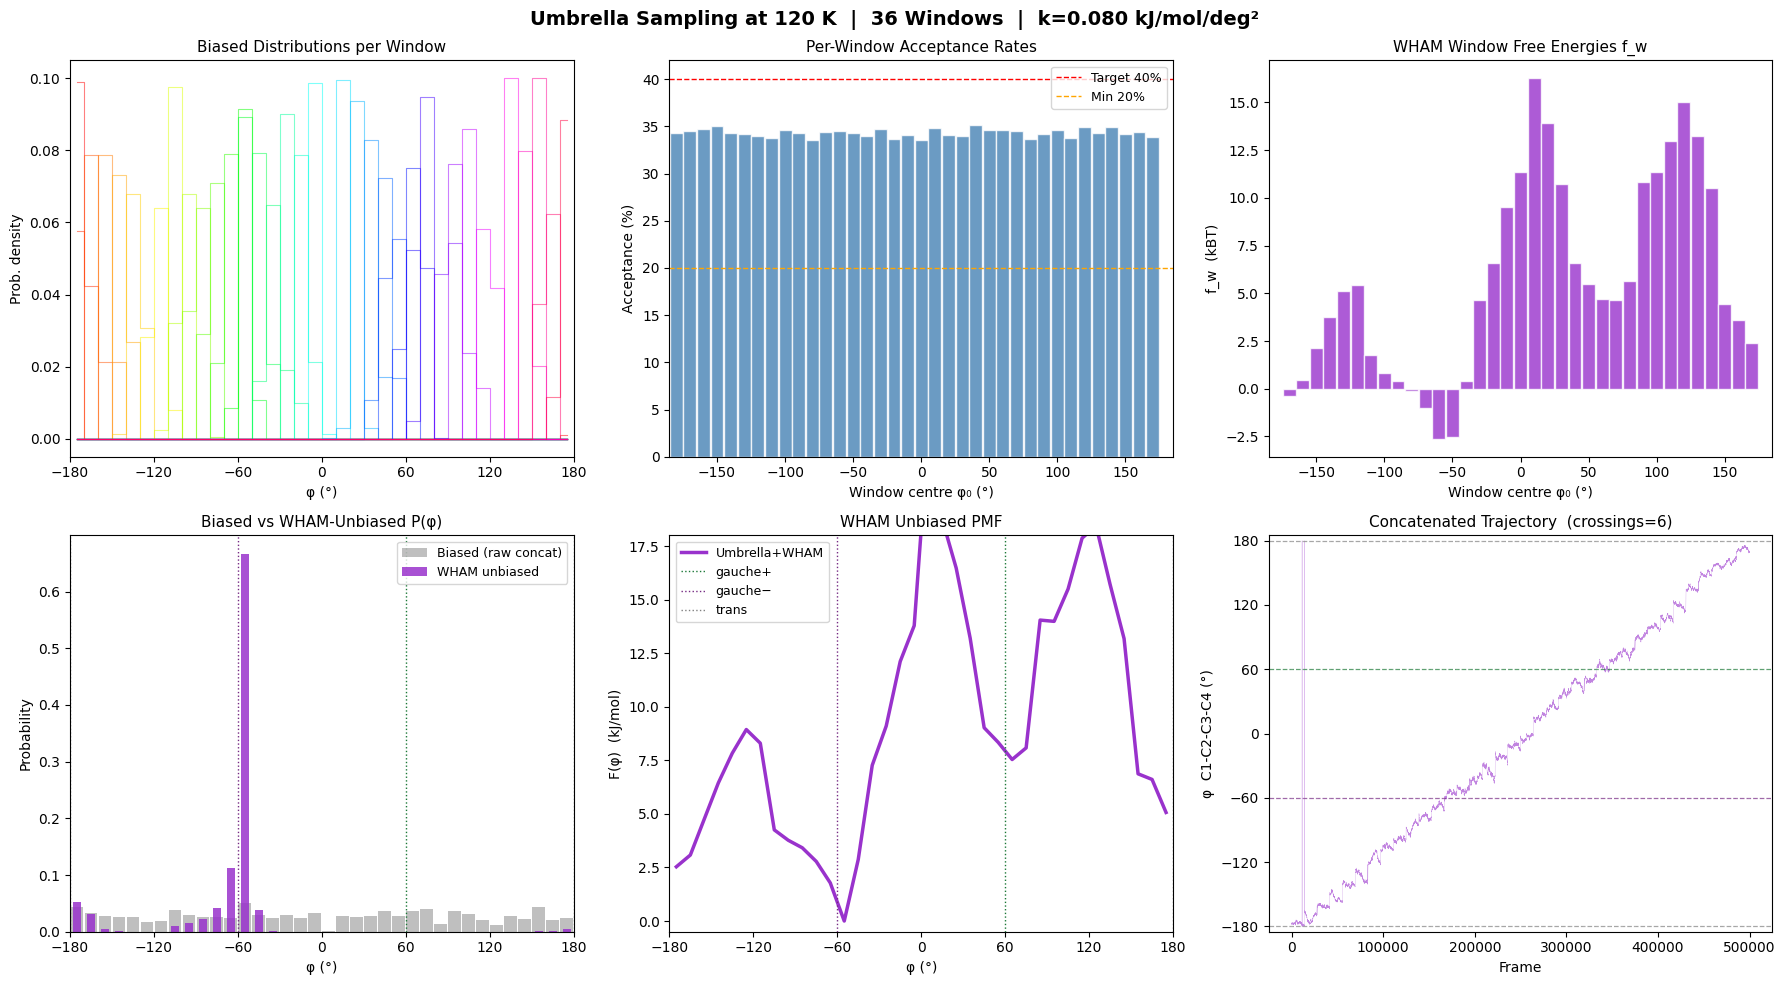

Saved: enhanced_umbrella_120K.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 9 — Task 3: Enhanced Sampling via Umbrella Sampling + WHAM
#
# Method:
#   1. Divide [-180°, 180°] into N_WINDOWS umbrella windows
#   2. Each window runs a short independent MC simulation biased by a
#      harmonic restraint centred at phi_0:
#          V_umb(phi) = (k/2) * wrap(phi - phi_0)^2
#   3. Histograms from all windows are combined using the Weighted
#      Histogram Analysis Method (WHAM) to recover the unbiased
#      free energy profile F(phi) = PMF(phi)
#   4. The concatenated dihedral trajectory (all windows) feeds into
#      downstream cells (entropy, PMF, heatmap) via `enhanced_results`
#
# Compatibility: all downstream cells (10–13) use enhanced_results[T]
#   keys: cold_dihedrals, centers (empty), heights (empty), acceptance,
#         crossings, bin_centers, p_biased, p_unbias
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from concurrent.futures import ProcessPoolExecutor
import os

# ── Umbrella bias energy & force ──────────────────────────────────────────────

def _wrap180(diff):
    """Wrap angular difference to [-180, 180] degrees."""
    return (diff + 180.0) % 360.0 - 180.0

def umbrella_bias(phi, phi0, k_umb):
    """
    Harmonic umbrella potential (degrees → kJ/mol):
        V_umb(phi) = (k/2) * wrap(phi - phi0)^2

    k_umb is in kJ/mol/deg^2.
    """
    d = _wrap180(phi - phi0)
    return 0.5 * k_umb * d**2

# ── Single-window umbrella MC (vectorized RNG) ────────────────────────────────

def run_umbrella_window(positions, T, phi0, k_umb,
                        n_steps=200000 // 36,
                        n_equil=3000,
                        max_disp=0.050,
                        adaptive=True,
                        target_acceptance=0.40,
                        adapt_interval=300,
                        seed=0):
    """
    NVT MC with a harmonic umbrella bias on the backbone dihedral C1-C2-C3-C4.

        E_eff(trial) = E_pot(trial) + V_umb(phi_trial)

    Parameters
    ----------
    positions : np.ndarray (5,3)  — starting configuration
    T         : float             — temperature (K)
    phi0      : float             — window centre (degrees)
    k_umb     : float             — spring constant (kJ/mol/deg²)
    n_steps   : int               — production steps (after equilibration)
    n_equil   : int               — equilibration steps (discarded)
    ...

    Returns
    -------
    dihedrals : np.ndarray (n_steps,)   — unbiased CV values in this window
    energies  : np.ndarray (n_steps,)   — unbiased potential energies
    acceptance: float
    """
    rng       = np.random.default_rng(seed)
    positions = positions.copy()
    beta      = 1.0 / (kB_kJ * T)

    E_pot = total_energy(positions)
    phi   = compute_dihedral(positions[1], positions[2],
                             positions[3], positions[4])

    total_steps = n_equil + n_steps

    # ── Pre-generate all random numbers up front (vectorized) ─────────────
    all_atoms  = rng.integers(0, 5, size=total_steps)
    all_deltas = (rng.random((total_steps, 3)) * 2.0 - 1.0) * max_disp
    all_unifrn = rng.random(total_steps)

    accepted        = 0
    accepted_window = 0

    dihedrals = np.zeros(n_steps)
    energies  = np.zeros(n_steps)

    for step in range(total_steps):

        # ── Propose move (from pre-generated arrays) ───────────────────────
        atom        = all_atoms[step]
        delta       = all_deltas[step]
        trial       = positions.copy()
        trial[atom] += delta

        E_trial   = total_energy(trial)
        phi_trial = compute_dihedral(trial[1], trial[2],
                                     trial[3], trial[4])

        # ── Biased Metropolis ─────────────────────────────────────────────
        V_curr  = umbrella_bias(phi,       phi0, k_umb)
        V_trial = umbrella_bias(phi_trial, phi0, k_umb)
        dE_eff  = (E_trial + V_trial) - (E_pot + V_curr)

        if dE_eff <= 0.0 or all_unifrn[step] < np.exp(-beta * dE_eff):
            positions = trial
            E_pot     = E_trial
            phi       = phi_trial
            accepted        += 1
            accepted_window += 1

        # ── Record (production only) ──────────────────────────────────────
        if step >= n_equil:
            idx            = step - n_equil
            dihedrals[idx] = phi
            energies[idx]  = E_pot

    return dihedrals, energies, accepted / total_steps


# ── Top-level worker for ProcessPoolExecutor (must be picklable) ─────────────

def _window_worker(args):
    """Unpacks args and calls run_umbrella_window. Top-level so pickle works."""
    pos, T, phi0, k_umb, n_steps, n_equil, max_disp, adaptive, seed = args
    return run_umbrella_window(
        positions  = pos,
        T          = T,
        phi0       = phi0,
        k_umb      = k_umb,
        n_steps    = n_steps,
        n_equil    = n_equil,
        max_disp   = max_disp,
        adaptive   = adaptive,
        seed       = seed,
    )


# ── WHAM: Weighted Histogram Analysis Method ─────────────────────────────────-

def run_WHAM(window_dihedrals, window_phi0s, k_umb, T,
             n_bins=36, n_iter=5000, tol=1e-8):
    """
    Self-consistent WHAM to combine umbrella windows into an unbiased PMF.

    WHAM equations (Kumar et al. 1992):
        P_unbiased(phi_i) = sum_w n_w * p_w(phi_i)
                          / sum_w N_w * exp(-beta * V_umb_w(phi_i) + f_w)

        exp(-f_w) = sum_i P(phi_i) * exp(-beta * V_umb_w(phi_i))

    Iterates until the free energy offsets f_w converge.

    Parameters
    ----------
    window_dihedrals : list of np.ndarray — dihedral trajectories per window
    window_phi0s     : list of float      — window centres (degrees)
    k_umb            : float              — spring constant (kJ/mol/deg²)
    T                : float              — temperature (K)
    n_bins           : int                — histogram bins
    n_iter           : int                — max WHAM iterations
    tol              : float              — convergence threshold on f_w

    Returns
    -------
    bin_centers  : np.ndarray (n_bins,)
    pmf          : np.ndarray (n_bins,)   — unbiased PMF in kJ/mol (min=0)
    P_unbiased   : np.ndarray (n_bins,)   — unbiased probability
    f_w          : np.ndarray (n_win,)    — converged window free energies
    """
    beta      = 1.0 / (kB_kJ * T)
    bin_edges = np.linspace(-180.0, 180.0, n_bins + 1)
    bin_ctrs  = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    n_win     = len(window_dihedrals)

    # Raw histogram counts per window, shape (n_win, n_bins)
    counts = np.zeros((n_win, n_bins))
    N_w    = np.zeros(n_win)
    for w, d in enumerate(window_dihedrals):
        c, _ = np.histogram(d, bins=bin_edges)
        counts[w] = c
        N_w[w]    = len(d)

    # Bias matrix: B[w, i] = exp(-beta * V_umb_w(phi_i))
    # shape (n_win, n_bins)
    B = np.zeros((n_win, n_bins))
    for w, phi0 in enumerate(window_phi0s):
        d_ang  = _wrap180(bin_ctrs - phi0)
        V_vals = 0.5 * k_umb * d_ang**2
        B[w]   = np.exp(-beta * V_vals)

    # WHAM self-consistent iteration
    f_w = np.zeros(n_win)

    for iteration in range(n_iter):
        denom = np.sum(N_w[:, None] * B * np.exp(f_w)[:, None], axis=0)
        numer = np.sum(counts, axis=0).astype(float)

        with np.errstate(divide='ignore', invalid='ignore'):
            P_unbiased = np.where(denom > 0, numer / denom, 0.0)

        P_total = P_unbiased.sum()
        if P_total > 0:
            P_unbiased /= P_total

        inner     = P_unbiased[None, :] * B
        row_sums  = inner.sum(axis=1)
        f_w_new   = np.where(row_sums > 0, -np.log(row_sums), f_w)
        f_w_new  -= f_w_new[0]

        delta = np.max(np.abs(f_w_new - f_w))
        f_w   = f_w_new
        if delta < tol:
            print(f"    WHAM converged in {iteration+1} iterations  (Δf = {delta:.2e})")
            break
    else:
        print(f"    WHAM reached max iterations ({n_iter})  (Δf = {delta:.2e})")

    with np.errstate(divide='ignore', invalid='ignore'):
        pmf = np.where(P_unbiased > 0,
                       -kB_kJ * T * np.log(P_unbiased),
                       np.nan)
    pmf -= np.nanmin(pmf)

    return bin_ctrs, pmf, P_unbiased, f_w


# ── Run full umbrella sampling pipeline ─────────────────────────────────────--

def run_umbrella_sampling(T, n_windows=36,
                          k_umb=0.10,
                          max_disp=0.0150,
                          steps_per_window=None,
                          n_equil=3000,
                          total_steps=200000,
                          seed_base=0):

    if steps_per_window is None:
        steps_per_window = max(total_steps // n_windows, 1000)

    phi0s = np.linspace(-180.0, 180.0, n_windows, endpoint=False)

    print(f"\n  Umbrella Sampling at {T} K")
    print(f"  {n_windows} windows × {steps_per_window} steps  "
          f"|  k_umb = {k_umb:.4f} kJ/mol/deg²")

    # ── Window 0: run sequentially first and print ────────────────────────
    phi0_0   = phi0s[0]
    pos_0    = build_pentane(phi1=phi0_0, phi2=180.0)
    d0, e0, acc0 = run_umbrella_window(
        positions = pos_0,
        T         = T,
        phi0      = phi0_0,
        k_umb     = k_umb,
        n_steps   = steps_per_window,
        n_equil   = n_equil,
        max_disp  = max_disp,
        adaptive  = True,
        seed      = seed_base + 0,
    )
    print(f"    Window  1/{n_windows}  "
          f"φ₀={phi0_0:>7.1f}°  "
          f"mean_φ={d0.mean():>7.1f}°  "
          f"acc={acc0*100:.1f}%")

    # ── Windows 1–N: run in parallel ──────────────────────────────────────
    worker_args = [
        (
            build_pentane(phi1=phi0, phi2=180.0),
            T, phi0, k_umb,
            steps_per_window, n_equil,
            max_disp, True,
            seed_base + w_idx,
        )
        for w_idx, phi0 in enumerate(phi0s[1:], start=1)
    ]

    n_workers = min(max(os.cpu_count() - 1, 1), n_windows - 1)
    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        rest = list(pool.map(_window_worker, worker_args))

    # ── Recombine in original window order ────────────────────────────────
    window_dihedrals = [d0]  + [r[0] for r in rest]
    window_energies  = [e0]  + [r[1] for r in rest]
    window_acc       = [acc0]+ [r[2] for r in rest]

    for w_idx, (phi0, acc, d) in enumerate(zip(phi0s[1:], window_acc[1:], window_dihedrals[1:]), start=1):
        if (w_idx + 1) % 9 == 0:
            print(f"    Window {w_idx+1:>2}/{n_windows}  "
                  f"φ₀={phi0:>7.1f}°  "
                  f"mean_φ={d.mean():>7.1f}°  "
                  f"acc={acc*100:.1f}%")

    print(f"  Mean acceptance: {np.mean(window_acc)*100:.1f}%")

    # ── WHAM ──────────────────────────────────────────────────────────────
    print(f"  Running WHAM ...")
    bin_ctrs, pmf_wham, P_unbiased, f_w = run_WHAM(
        window_dihedrals = window_dihedrals,
        window_phi0s     = phi0s,
        k_umb            = k_umb,
        T                = T,
        n_bins           = 36,
    )

    cold_dihedrals = np.concatenate(window_dihedrals)
    counts_raw, _  = np.histogram(cold_dihedrals, bins=np.linspace(-180,180,37))
    p_biased       = counts_raw / counts_raw.sum()
    crossings      = int(np.sum(np.abs(np.diff(cold_dihedrals)) > 90))

    return {
        'cold_dihedrals'  : cold_dihedrals,
        'cold_energies'   : np.concatenate(window_energies),
        'centers'         : [],
        'heights'         : [],
        'wham_bin_ctrs'   : bin_ctrs,
        'wham_pmf'        : pmf_wham,
        'wham_P'          : P_unbiased,
        'wham_f_w'        : f_w,
        'window_dihedrals': window_dihedrals,
        'window_phi0s'    : phi0s,
        'window_acc'      : window_acc,
        'k_umb'           : k_umb,
        'acceptance'      : float(np.mean(window_acc)),
        'crossings'       : crossings,
        'bin_centers'     : bin_ctrs,
        'p_biased'        : p_biased,
        'p_unbias'        : P_unbiased,
        'T_list'          : [T],
        'swap_stats'      : {},
    }


# ─────────────────────────────────────────────────────────────────────────────
# Run umbrella sampling at both temperatures
# ─────────────────────────────────────────────────────────────────────────────

enhanced_results = {}

for T in [120, 250]:
    enhanced_results[T] = run_umbrella_sampling(
        T               = T,
        n_windows       = 36,
        k_umb           = 0.08,
        max_disp        = 0.0050,
        total_steps     = 500000,
        n_equil         = 2000,
        seed_base       = 42,
    )


# ─────────────────────────────────────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────────────────────────────────────

phi_scan    = np.linspace(-180, 180, 361)
BIN_EDGES   = np.linspace(-180, 180, 37)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])
BAR_W = 360/36 - 0.8

for T in [120, 250]:
    er  = enhanced_results[T]
    n_w = len(er['window_phi0s'])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Umbrella Sampling at {T} K  |  36 Windows  |  k={er['k_umb']:.3f} kJ/mol/deg²",
                 fontsize=14, fontweight='bold')

    # ── (0,0) All window dihedral distributions ──────────────────────────
    ax = axes[0, 0]
    cmap = plt.cm.hsv
    for w_idx, (d, phi0) in enumerate(zip(er['window_dihedrals'],
                                           er['window_phi0s'])):
        c, _ = np.histogram(d, bins=BIN_EDGES, density=True)
        ax.step(BIN_CENTERS, c, where='mid', lw=0.8, alpha=0.5,
                color=cmap(w_idx / n_w))
    ax.set_title("Biased Distributions per Window", fontsize=11)
    ax.set_xlabel("φ (°)"); ax.set_ylabel("Prob. density")
    ax.set_xlim(-180, 180); ax.set_xticks(np.arange(-180, 181, 60))

    # ── (0,1) Window acceptance rates ────────────────────────────────────
    ax = axes[0, 1]
    ax.bar(er['window_phi0s'], np.array(er['window_acc'])*100,
           width=360/n_w - 0.5, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axhline(40, color='red',   ls='--', lw=1, label='Target 40%')
    ax.axhline(20, color='orange',ls='--', lw=1, label='Min 20%')
    ax.set_title("Per-Window Acceptance Rates", fontsize=11)
    ax.set_xlabel("Window centre φ₀ (°)"); ax.set_ylabel("Acceptance (%)")
    ax.set_xlim(-185, 185); ax.legend(fontsize=9)

    # ── (0,2) WHAM free energies f_w ─────────────────────────────────────
    ax = axes[0, 2]
    ax.bar(er['window_phi0s'], er['wham_f_w'],
           width=360/n_w - 0.5, color='darkorchid', alpha=0.8, edgecolor='white')
    ax.set_title("WHAM Window Free Energies f_w", fontsize=11)
    ax.set_xlabel("Window centre φ₀ (°)"); ax.set_ylabel("f_w  (kBT)")
    ax.set_xlim(-185, 185)

    # ── (1,0) Biased vs WHAM-unbiased histogram ──────────────────────────
    ax = axes[1, 0]
    ax.bar(BIN_CENTERS, er['p_biased'], width=BAR_W,
           color='gray', alpha=0.5, label='Biased (raw concat)')
    ax.bar(BIN_CENTERS, er['wham_P'],
           width=BAR_W*0.6, color='darkorchid', alpha=0.85,
           label='WHAM unbiased')
    for xv, c in [(60,'#1b7837'),(-60,'#762a83'),(180,'gray'),(-180,'gray')]:
        ax.axvline(xv, color=c, ls=':', lw=1)
    ax.set_title("Biased vs WHAM-Unbiased P(φ)", fontsize=11)
    ax.set_xlabel("φ (°)"); ax.set_ylabel("Probability")
    ax.set_xlim(-180, 180); ax.set_xticks(np.arange(-180, 181, 60))
    ax.legend(fontsize=9)

    # ── (1,1) WHAM PMF alone ──────────────────────────────────────────────
    ax = axes[1, 1]
    ax.plot(er['wham_bin_ctrs'], er['wham_pmf'],
            color='darkorchid', ls='-', lw=2.5, label='Umbrella+WHAM')
    for xv, c, lbl in [(60,'#1b7837','gauche+'),(-60,'#762a83','gauche−'),
                        (180,'gray','trans')]:
        ax.axvline(xv, color=c, ls=':', lw=1, label=lbl)
    ax.set_title("WHAM Unbiased PMF", fontsize=11)
    ax.set_xlabel("φ (°)"); ax.set_ylabel("F(φ)  (kJ/mol)")
    ax.set_xlim(-180, 180); ax.set_xticks(np.arange(-180, 181, 60))
    ax.set_ylim(-0.5, 18); ax.legend(fontsize=9)

    # ── (1,2) Concatenated trajectory time series ─────────────────────────
    ax = axes[1, 2]
    d_full = er['cold_dihedrals']
    ax.plot(d_full, lw=0.2, alpha=0.6, color='darkorchid', rasterized=True)
    for yv, c in [(180,'gray'),(-180,'gray'),(60,'#1b7837'),(-60,'#762a83')]:
        ax.axhline(yv, color=c, ls='--', lw=0.9, alpha=0.7)
    for boundary in np.linspace(-180, 180, n_w+1):
        ax.axvline(boundary * len(d_full)/360 + len(d_full)/2,
                   color='white', lw=0.3, alpha=0.4)
    ax.set_title(f"Concatenated Trajectory  (crossings={er['crossings']})", fontsize=11)
    ax.set_xlabel("Frame"); ax.set_ylabel("φ  C1-C2-C3-C4 (°)")
    ax.set_ylim(-185, 185); ax.set_yticks([-180,-120,-60,0,60,120,180])

    plt.tight_layout()
    fname = f"enhanced_umbrella_{T}K.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

### Exploration entropy metrics
Computes entropy-based exploration scores, prints metrics, and plots entropy and bin coverage over time.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 10 — Task 4a: Exploration Entropy & Early Exploration Score
# ─────────────────────────────────────────────────────────────────────────────

# ── Constants ─────────────────────────────────────────────────────────────────
N_BINS      = 36
BIN_EDGES   = np.linspace(-180, 180, N_BINS + 1)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])
LOG2        = np.log(2)                      # for converting nats → bits if needed
S_MAX       = np.log(N_BINS)                 # maximum possible entropy = ln(36) ≈ 3.58 nats

# ── Core entropy function ─────────────────────────────────────────────────────

def compute_entropy(dihedrals, n_bins=N_BINS):
    """
    Shannon entropy of the dihedral distribution (in nats):
        S = -sum_i  P_i * ln(P_i)

    Empty bins are excluded (0*ln(0) → 0 by convention).
    Maximum value: ln(36) ≈ 3.58 nats  (perfectly flat histogram).

    Parameters
    ----------
    dihedrals : array-like  — dihedral angle samples (degrees)
    n_bins    : int         — number of equal bins over [-180, 180]

    Returns
    -------
    S : float  — entropy in nats
    """
    counts, _ = np.histogram(dihedrals,
                              bins=n_bins,
                              range=(-180.0, 180.0))
    total = counts.sum()
    if total == 0:
        return 0.0
    probs = counts / total
    probs = probs[probs > 0]          # exclude empty bins
    return float(-np.sum(probs * np.log(probs)))


def compute_entropy_normalised(dihedrals, n_bins=N_BINS):
    """
    Returns entropy normalised to [0, 1] relative to the flat histogram:
        S_norm = S / ln(n_bins)
    Useful for comparing across different bin counts.
    """
    return compute_entropy(dihedrals, n_bins) / np.log(n_bins)


# ── Early exploration score (project definition) ─────────────────────────────

def early_exploration_score(dihedrals, n_bins=N_BINS,
                             subsample=50):
    """
    Early Exploration Score as defined in the project:
        E = (1/T) * sum_{t=1}^{T}  S(t)
    where S(t) is the entropy computed using all samples up to step t.

    Computing S(t) for every single t is O(N²) in cost.
    `subsample` controls how many equally-spaced checkpoints are used
    to approximate the integral cheaply (default: every 50 steps).

    Parameters
    ----------
    dihedrals  : np.ndarray (N,)   — full dihedral trajectory
    n_bins     : int
    subsample  : int               — compute S every `subsample` steps

    Returns
    -------
    E          : float             — early exploration score (nats)
    S_curve    : np.ndarray        — entropy at each checkpoint
    checkpoints: np.ndarray        — step indices of checkpoints
    """
    N           = len(dihedrals)
    checkpoints = np.arange(subsample, N + 1, subsample)
    S_curve     = np.array([compute_entropy(dihedrals[:t], n_bins)
                             for t in checkpoints])

    # Mean over checkpoints approximates the average in the project definition
    E = float(np.mean(S_curve))
    return E, S_curve, checkpoints


# ── Convergence helper: fraction of bins visited ─────────────────────────────

def bins_visited_over_time(dihedrals, n_bins=N_BINS, subsample=50):
    """
    Returns the fraction of the 36 dihedral bins that have been
    visited at least once by step t.  A complementary metric to entropy.
    """
    N           = len(dihedrals)
    checkpoints = np.arange(subsample, N + 1, subsample)
    fractions   = []
    for t in checkpoints:
        counts, _ = np.histogram(dihedrals[:t], bins=n_bins, range=(-180,180))
        fractions.append(np.sum(counts > 0) / n_bins)
    return np.array(fractions), checkpoints


# ── Run entropy analysis for all methods ─────────────────────────────────────

METHODS = {}   # will hold {label: dihedrals_array}

for T in [120, 250]:
    METHODS[f'MC_{T}K']       = results[f'MC_{T}']['dihedrals']
    METHODS[f'MD_{T}K']       = results[f'MD_{T}']['dihedrals']
    METHODS[f'Enhanced_{T}K'] = enhanced_results[T]['cold_dihedrals']

# Compute all metrics
metrics = {}

for label, d in METHODS.items():
    S_final  = compute_entropy(d)
    S_norm   = compute_entropy_normalised(d)
    E, S_curve, chk = early_exploration_score(d, subsample=50)
    frac, _  = bins_visited_over_time(d, subsample=50)

    metrics[label] = {
        'S_final'  : S_final,
        'S_norm'   : S_norm,
        'E'        : E,
        'S_curve'  : S_curve,
        'checkpoints': chk,
        'frac_visited': frac,
        'dihedrals': d,
    }


# ─────────────────────────────────────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────────────────────────────────────

STYLE = {
    'MC_120K'      : {'color': '#2166ac', 'ls': '-',  'lw': 2.0},
    'MD_120K'      : {'color': '#4dac26', 'ls': '--', 'lw': 2.0},
    'Enhanced_120K': {'color': '#b2182b', 'ls': '-',  'lw': 2.5},
    'MC_250K'      : {'color': '#74add1', 'ls': '-',  'lw': 2.0},
    'MD_250K'      : {'color': '#a6d96a', 'ls': '--', 'lw': 2.0},
    'Enhanced_250K': {'color': '#f46d43', 'ls': '-',  'lw': 2.5},
}

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
fig.suptitle("Task 4a — Exploration Entropy & Early Exploration Score",
             fontsize=14, fontweight='bold')

# ── Row 0: 120 K ─────────────────────────────────────────────────────────────

# (0,0) Entropy over time — 120 K
ax = axes[0, 0]
for label in ['MC_120K', 'MD_120K', 'Enhanced_120K']:
    m   = metrics[label]
    ax.plot(m['checkpoints'], m['S_curve'],
            label=f"{label}  (E={m['E']:.3f})",
            **STYLE[label])
ax.axhline(S_MAX, color='black', ls=':', lw=1, label=f'S_max=ln(36)={S_MAX:.2f}')
ax.set_title("Entropy S(t) over Time — 120 K", fontsize=12)
ax.set_xlabel("MC/MD Step", fontsize=10)
ax.set_ylabel("Entropy S (nats)", fontsize=10)
ax.set_ylim(0, S_MAX * 1.1)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# (0,1) Bins visited over time — 120 K
ax = axes[0, 1]
for label in ['MC_120K', 'MD_120K', 'Enhanced_120K']:
    m = metrics[label]
    ax.plot(m['checkpoints'], m['frac_visited'] * 100,
            label=label, **STYLE[label])
ax.axhline(100, color='black', ls=':', lw=1, label='100% (all bins)')
ax.set_title("Fraction of Bins Visited — 120 K", fontsize=12)
ax.set_xlabel("MC/MD Step", fontsize=10)
ax.set_ylabel("Bins visited (%)", fontsize=10)
ax.set_ylim(0, 110)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))


# ── Row 1: 250 K ─────────────────────────────────────────────────────────────

# (1,0) Entropy over time — 250 K
ax = axes[1, 0]
for label in ['MC_250K', 'MD_250K', 'Enhanced_250K']:
    m = metrics[label]
    ax.plot(m['checkpoints'], m['S_curve'],
            label=f"{label}  (E={m['E']:.3f})",
            **STYLE[label])
ax.axhline(S_MAX, color='black', ls=':', lw=1, label=f'S_max={S_MAX:.2f}')
ax.set_title("Entropy S(t) over Time — 250 K", fontsize=12)
ax.set_xlabel("MC/MD Step", fontsize=10)
ax.set_ylabel("Entropy S (nats)", fontsize=10)
ax.set_ylim(0, S_MAX * 1.1)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# (1,1) Bins visited over time — 250 K
ax = axes[1, 1]
for label in ['MC_250K', 'MD_250K', 'Enhanced_250K']:
    m = metrics[label]
    ax.plot(m['checkpoints'], m['frac_visited'] * 100,
            label=label, **STYLE[label])
ax.axhline(100, color='black', ls=':', lw=1)
ax.set_title("Fraction of Bins Visited — 250 K", fontsize=12)
ax.set_xlabel("MC/MD Step", fontsize=10)
ax.set_ylabel("Bins visited (%)", fontsize=10)
ax.set_ylim(0, 110)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig("plots/entropy_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/entropy_analysis.png")


# ── Summary table ─────────────────────────────────────────────────────────────

print(f"\n{'═'*75}")
print("TASK 4a — FINAL SUMMARY TABLE")
print(f"{'═'*75}")
print(f"{'Method':<20} {'T(K)':>6} {'Final S':>9} {'S_norm':>8} "
      f"{'Early E':>10} {'Bins%':>8} {'Crossings':>10}")
print(f"{'─'*75}")

for T in [120, 250]:
    for prefix in ['MC', 'MD', 'Enhanced']:
        label = f'{prefix}_{T}K'
        m  = metrics[label]
        # Crossings
        d  = m['dihedrals']
        cr = int(np.sum(np.abs(np.diff(d)) > 90))
        print(f"{label:<20} {T:>6} {m['S_final']:>9.4f} "
              f"{m['S_norm']:>8.4f} {m['E']:>10.4f} "
              f"{m['frac_visited'][-1]*100:>7.1f}% {cr:>10}")
    print(f"{'─'*75}")

NameError: name 'results' is not defined

### PMF via Boltzmann inversion
Builds PMFs for MC, MD, and enhanced sampling, compares to a reference torsion scan, and plots PMF and probability figures.

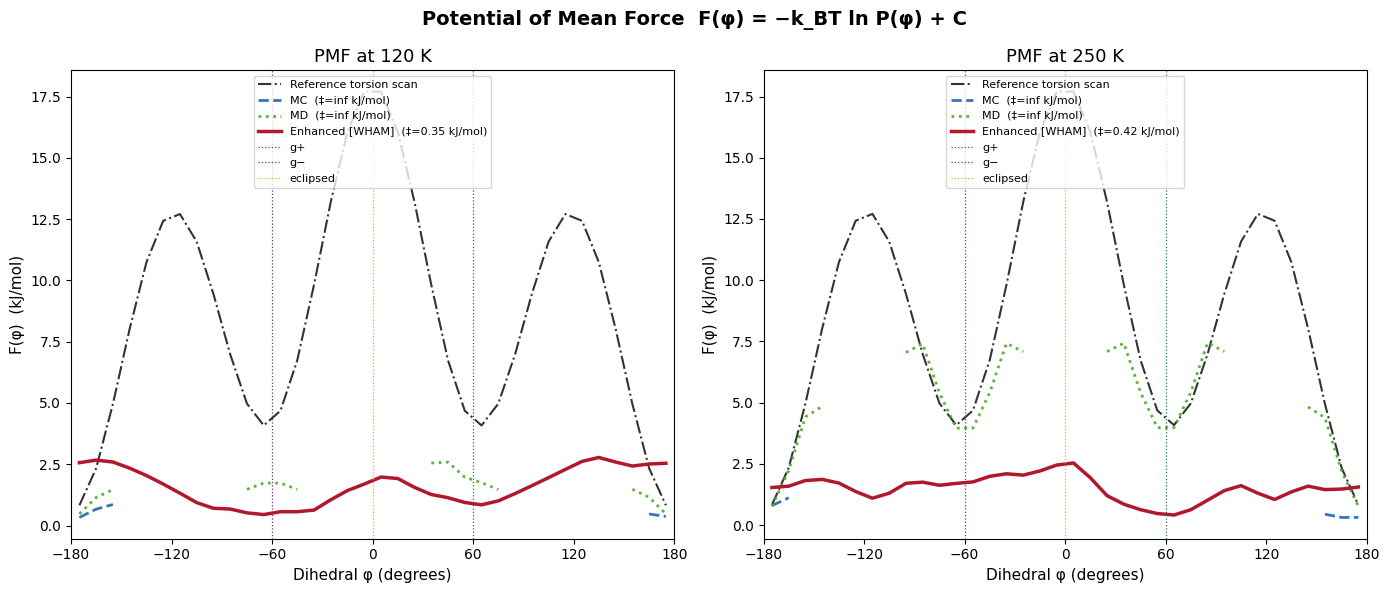

Saved: pmf_comparison.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 11 — Task 4b: Potential of Mean Force (PMF) via Boltzmann Inversion
#           Supports: Baseline MC/MD, Umbrella Sampling + WHAM, MetaDynamics
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ── Ensure MC/MD results are available ───────────────────────────────────────-

if 'results' not in globals():
    if 'mc_results' in globals() and 'md_results' in globals():
        results = {}
        for T in [120, 250]:
            if T not in mc_results or T not in md_results:
                raise KeyError(f"Missing MC/MD data for {T} K.")
            results[f'MC_{T}'] = {
                'dihedrals': mc_results[T]['dihedrals'],
                'energies': mc_results[T]['energies'],
                'acceptance': mc_results[T].get('acceptance', float('nan')),
            }
            results[f'MD_{T}'] = {
                'dihedrals': md_results[T]['dihedrals'],
                'energies': md_results[T]['energies'],
                'acceptance': md_results[T].get('acceptance', float('nan')),
            }
        print("Rebuilt results from mc_results/md_results for PMF analysis.")
    else:
        raise NameError("results is not defined. Run the MC and MD baseline cells first.")

# ── Detect which enhanced sampling method was used ───────────────────────────

def _is_umbrella(enhanced_result):
    """
    Returns True if Cell 9 used umbrella sampling (empty centers/heights),
    False if it used metadynamics-style Gaussian bias.
    """
    return (len(enhanced_result.get('centers', [])) == 0 and
            len(enhanced_result.get('heights', [])) == 0)


# ── eval_bias_array: safe for both methods ────────────────────────────────────

def eval_bias_array(dihedrals, bias_centers, bias_heights, sigma_meta):
    """
    Evaluates the cumulative Gaussian metadynamics bias at each frame.
    Returns an array of zeros if no Gaussian bias was deposited
    (i.e. umbrella sampling was used in Cell 9).

        V_bias(φ_i) = Σ_t  h_t · exp(−(φ_i − φ_t)² / 2σ²)

    Parameters
    ----------
    dihedrals    : np.ndarray (N,)   dihedral angles in degrees
    bias_centers : list of float     deposited Gaussian centres (degrees)
    bias_heights : list of float     deposited Gaussian heights (kJ/mol)
    sigma_meta   : float             Gaussian width (degrees)

    Returns
    -------
    V_bias : np.ndarray (N,)   bias energy per frame (kJ/mol)
    """
    dihedrals = np.asarray(dihedrals)

    # Umbrella sampling path: no bias hills were deposited
    if len(bias_centers) == 0 or len(bias_heights) == 0:
        return np.zeros(len(dihedrals))

    centers = np.asarray(bias_centers)  # (M,)
    heights = np.asarray(bias_heights)  # (M,)

    # Vectorised evaluation with periodic wrapping — shape (N, M)
    diff   = dihedrals[:, None] - centers[None, :]
    diff   = (diff + 180.0) % 360.0 - 180.0          # wrap to [-180, 180]
    V_bias = np.sum(heights * np.exp(-diff**2 / (2.0 * sigma_meta**2)),
                    axis=1)
    return V_bias


# ── Core PMF via Boltzmann inversion ─────────────────────────────────────────

def compute_PMF(dihedrals, T, n_bins=36, weights=None, smooth_sigma=0.0):
    """
    PMF via Boltzmann inversion:
        F(φ) = −k_B T ln P(φ) + C,   min(F) = 0

    Optionally accepts per-frame importance weights for reweighting
    (MetaDynamics: w_i = exp(+V_bias/kBT)).

    Parameters
    ----------
    dihedrals    : np.ndarray (N,)
    T            : float              temperature (K)
    n_bins       : int                histogram bins (default: 36)
    weights      : np.ndarray or None per-frame weights (None = uniform)
    smooth_sigma : float              periodic Gaussian smoothing width
                                      in bin units (0 = no smoothing)
    Returns
    -------
    bin_centers : np.ndarray (n_bins,)
    pmf         : np.ndarray (n_bins,)   kJ/mol, min = 0
    probs       : np.ndarray (n_bins,)   normalised probability
    """
    bin_edges   = np.linspace(-180.0, 180.0, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Build histogram
    if weights is None:
        counts, _ = np.histogram(dihedrals, bins=bin_edges)
        counts    = counts.astype(float)
    else:
        counts, _ = np.histogram(dihedrals, bins=bin_edges,
                                 weights=np.asarray(weights, dtype=float))

    total = counts.sum()
    probs = np.where(counts > 0, counts / total, np.nan)

    # Periodic Gaussian smoothing
    if smooth_sigma > 0:
        nan_mask = np.isnan(probs)
        p_tmp    = np.where(nan_mask, 0.0, probs)
        p_tiled  = np.tile(p_tmp, 3)
        p_smooth = gaussian_filter1d(p_tiled, sigma=smooth_sigma)
        probs    = p_smooth[n_bins: 2 * n_bins]
        probs    = np.where(nan_mask, np.nan, probs)
        probs    = np.where(probs > 0, probs, np.nan)

    pmf  = -kB_kJ * T * np.log(probs)
    pmf -= np.nanmin(pmf)
    return bin_centers, pmf, probs


# ── Unbiased PMF dispatcher: MetaDynamics OR Umbrella Sampling ───────────────

def compute_PMF_unbiased(dihedrals, bias_centers, bias_heights,
                          sigma_meta, T, n_bins=36, smooth_sigma=0.8,
                          wham_result=None):
    """
    Compute the unbiased PMF, dispatching on enhanced sampling method:

    Umbrella Sampling (centers=[]):
        Uses the WHAM PMF directly from wham_result (precomputed in Cell 9).
        Falls back to plain Boltzmann inversion if wham_result is None.

    MetaDynamics (centers non-empty):
        Reweights per-frame using w_i = exp(+V_bias(φ_i)/k_BT), then
        calls compute_PMF with importance weights.

    Parameters
    ----------
    dihedrals    : np.ndarray (N,)
    bias_centers : list    Gaussian hill centres (empty for umbrella)
    bias_heights : list    Gaussian hill heights (empty for umbrella)
    sigma_meta   : float   MetaD Gaussian width (degrees)
    T            : float   temperature (K)
    wham_result  : tuple or None
                   Pre-computed (bin_centers, pmf, probs) from WHAM (Cell 9).
                   Required for umbrella sampling path.

    Returns
    -------
    (bin_centers, pmf, probs) tuple — same format as compute_PMF
    """
    # ── Umbrella sampling: use WHAM result ────────────────────────────────
    if len(bias_centers) == 0:
        if wham_result is not None:
            return wham_result   # already a (bin_centers, pmf, probs) tuple
        else:
            # Fallback: plain Boltzmann inversion on concatenated trajectory
            print("    → No WHAM result found; falling back to Boltzmann inversion")
            return compute_PMF(dihedrals, T, n_bins=n_bins,
                               smooth_sigma=smooth_sigma)

    # ── MetaDynamics: exponential reweighting ─────────────────────────────
    beta        = 1.0 / (kB_kJ * T)
    V_bias_traj = eval_bias_array(dihedrals, bias_centers,
                                  bias_heights, sigma_meta)
    weights     = np.exp(beta * V_bias_traj)
    return compute_PMF(dihedrals, T, n_bins=n_bins,
                       weights=weights, smooth_sigma=smooth_sigma)


# ── Reference PMF from torsion potential scan ─────────────────────────────────

def reference_PMF_torsion(T, n_bins=36):
    """
    Ground-truth PMF from a direct TraPPE-UA torsion energy scan:
        F_ref(φ) = V_tors(φ)  [at r=r0, θ=θ0, φ2=180°]
    """
    phi_vals    = np.linspace(-180, 180, n_bins + 1)
    bin_centers = 0.5 * (phi_vals[:-1] + phi_vals[1:])
    V_ref = np.array([torsion_energy(build_pentane(phi1=phi, phi2=180.0))
                      for phi in bin_centers])
    V_ref -= V_ref.min()
    # Return as 3-tuple to match compute_PMF output format
    return bin_centers, V_ref, None


# ── Compute PMFs for all methods ─────────────────────────────────────────────-

pmf_data = {}

for T in [120, 250]:
    er = enhanced_results[T]

    # ── Baseline MC ───────────────────────────────────────────────────────
    phi_mc = results[f'MC_{T}']['dihedrals']
    pmf_data[f'MC_{T}'] = compute_PMF(phi_mc, T, smooth_sigma=0.8)

    # ── Baseline MD ───────────────────────────────────────────────────────
    phi_md = results[f'MD_{T}']['dihedrals']
    pmf_data[f'MD_{T}'] = compute_PMF(phi_md, T, smooth_sigma=0.8)

    # Build the WHAM result tuple if umbrella sampling was used
    wham_result = None
    if _is_umbrella(er):
        wham_result = (
            er['wham_bin_ctrs'],
            er['wham_pmf'],
            er['wham_P'],
        )

    pmf_data[f'Enhanced_{T}'] = compute_PMF_unbiased(
        dihedrals    = er['cold_dihedrals'],
        bias_centers = er['centers'],
        bias_heights = er['heights'],
        sigma_meta   = 15.0,
        T            = T,
        smooth_sigma = 0.8,
        wham_result  = wham_result,
    )

    # ── Reference ─────────────────────────────────────────────────────────
    pmf_data[f'Reference_{T}'] = reference_PMF_torsion(T)


# ── barrier_heights ─────────────────────────────────────────────────────────--

def barrier_heights(bin_centers, pmf):
    """
    Returns (trans→gauche barrier, gauche energy relative to trans).
    Masks NaN bins before searching.
    """
    pmf_clean    = np.where(np.isnan(pmf), np.inf, pmf)
    trans_mask   = np.abs(bin_centers) > 150
    gauche_mask  = (np.abs(bin_centers) > 30)  & (np.abs(bin_centers) < 90)
    barrier_mask = (np.abs(bin_centers) > 90)  & (np.abs(bin_centers) < 150)

    trans_min  = np.min(pmf_clean[trans_mask])   if trans_mask.any()   else np.nan
    gauche_min = np.min(pmf_clean[gauche_mask])  if gauche_mask.any()  else np.nan
    barrier_h  = np.max(pmf_clean[barrier_mask]) if barrier_mask.any() else np.nan

    return barrier_h - trans_min, gauche_min - trans_min



# ── Shared style dict ─────────────────────────────────────────────────────────

STYLE = {
    'MC'        : {'color': '#2166ac', 'ls': '--', 'lw': 2.0, 'alpha': 0.9},
    'MD'        : {'color': '#4dac26', 'ls': ':',  'lw': 2.0, 'alpha': 0.9},
    'Enhanced'  : {'color': '#b2182b', 'ls': '-',  'lw': 2.5, 'alpha': 1.0},
    'Reference' : {'color': 'black',   'ls': '-.',  'lw': 1.5, 'alpha': 0.8},
}

def _smooth_periodic(y, sigma=1.0):
    """Periodic Gaussian smoothing with NaN preservation."""
    if sigma <= 0:
        return y
    y = np.asarray(y, dtype=float)
    nan_mask = np.isnan(y)
    y_tmp = np.where(nan_mask, 0.0, y)
    y_tiled = np.tile(y_tmp, 3)
    y_smooth = gaussian_filter1d(y_tiled, sigma=sigma)
    y_out = y_smooth[len(y): 2 * len(y)]
    y_out = np.where(nan_mask, np.nan, y_out)
    return y_out


# ── Figure 1: PMF comparison at 120 K and 250 K ─────────────────────────-----

fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))
fig1.suptitle("Potential of Mean Force  F(φ) = −k_BT ln P(φ) + C",
              fontsize=14, fontweight='bold')

for col, T in enumerate([120, 250]):
    ax = axes1[col]

    for prefix in ['Reference', 'MC', 'MD', 'Enhanced']:
        key       = f'{prefix}_{T}'
        bc, pmf_raw, *_ = pmf_data[key]
        pmf = _smooth_periodic(pmf_raw, sigma=1.0)
        s         = STYLE[prefix]

        # Enhanced label: show which method was used
        if prefix == 'Enhanced':
            method_tag = ('WHAM' if _is_umbrella(enhanced_results[T])
                          else 'MetaD-reweighted')
            b, g  = barrier_heights(bc, pmf)
            label = f'Enhanced [{method_tag}]  (‡={b:.2f} kJ/mol)'
        elif prefix == 'Reference':
            label = 'Reference torsion scan'
        else:
            b, g  = barrier_heights(bc, pmf)
            label = f'{prefix}  (‡={b:.2f} kJ/mol)'

        ax.plot(bc, pmf, label=label,
                color=s['color'], ls=s['ls'], lw=s['lw'], alpha=s['alpha'])

    for xv, lv, cv in [(60,'g+','#1b7837'), (-60,'g−','#762a83'),
                        (0,'eclipsed','orange')]:
        ax.axvline(xv, color=cv, ls=':', lw=0.9,
                   label=lv if lv else '_nolegend_')
    ax.set_title(f"PMF at {T} K", fontsize=13)
    ax.set_xlabel("Dihedral φ (degrees)", fontsize=11)
    ax.set_ylabel("F(φ)  (kJ/mol)", fontsize=11)
    ax.set_xlim(-180, 180)
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.legend(fontsize=8, loc='upper center')

plt.tight_layout()
plt.savefig("pmf_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pmf_comparison.png")

### Publication-quality comparison plots
Generates consolidated figures for time series, histograms, PMFs, and entropy with a consistent styling.

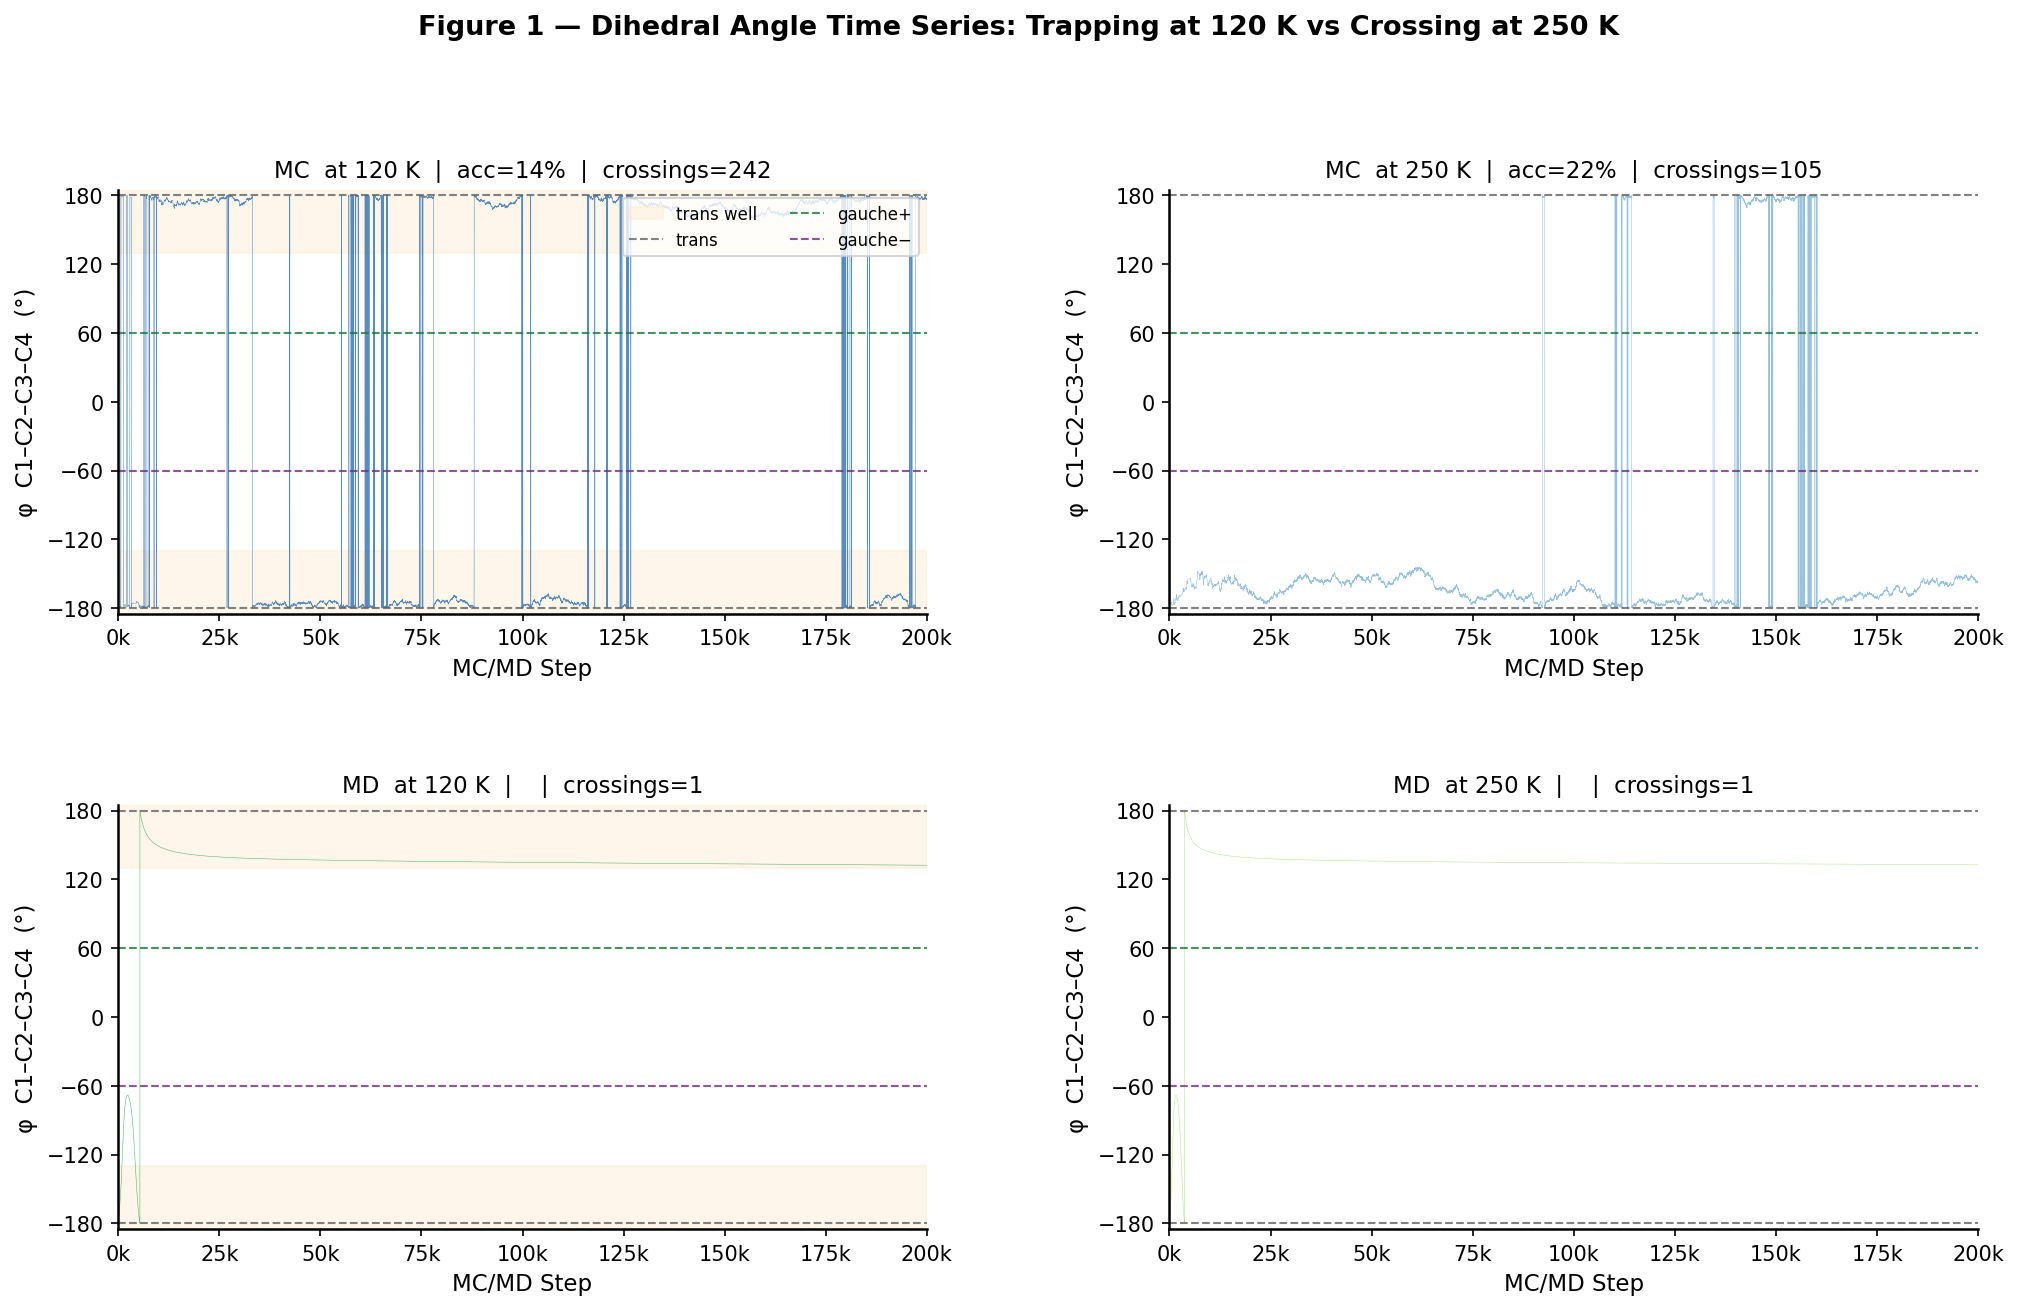

Saved: fig1_dihedral_timeseries.png


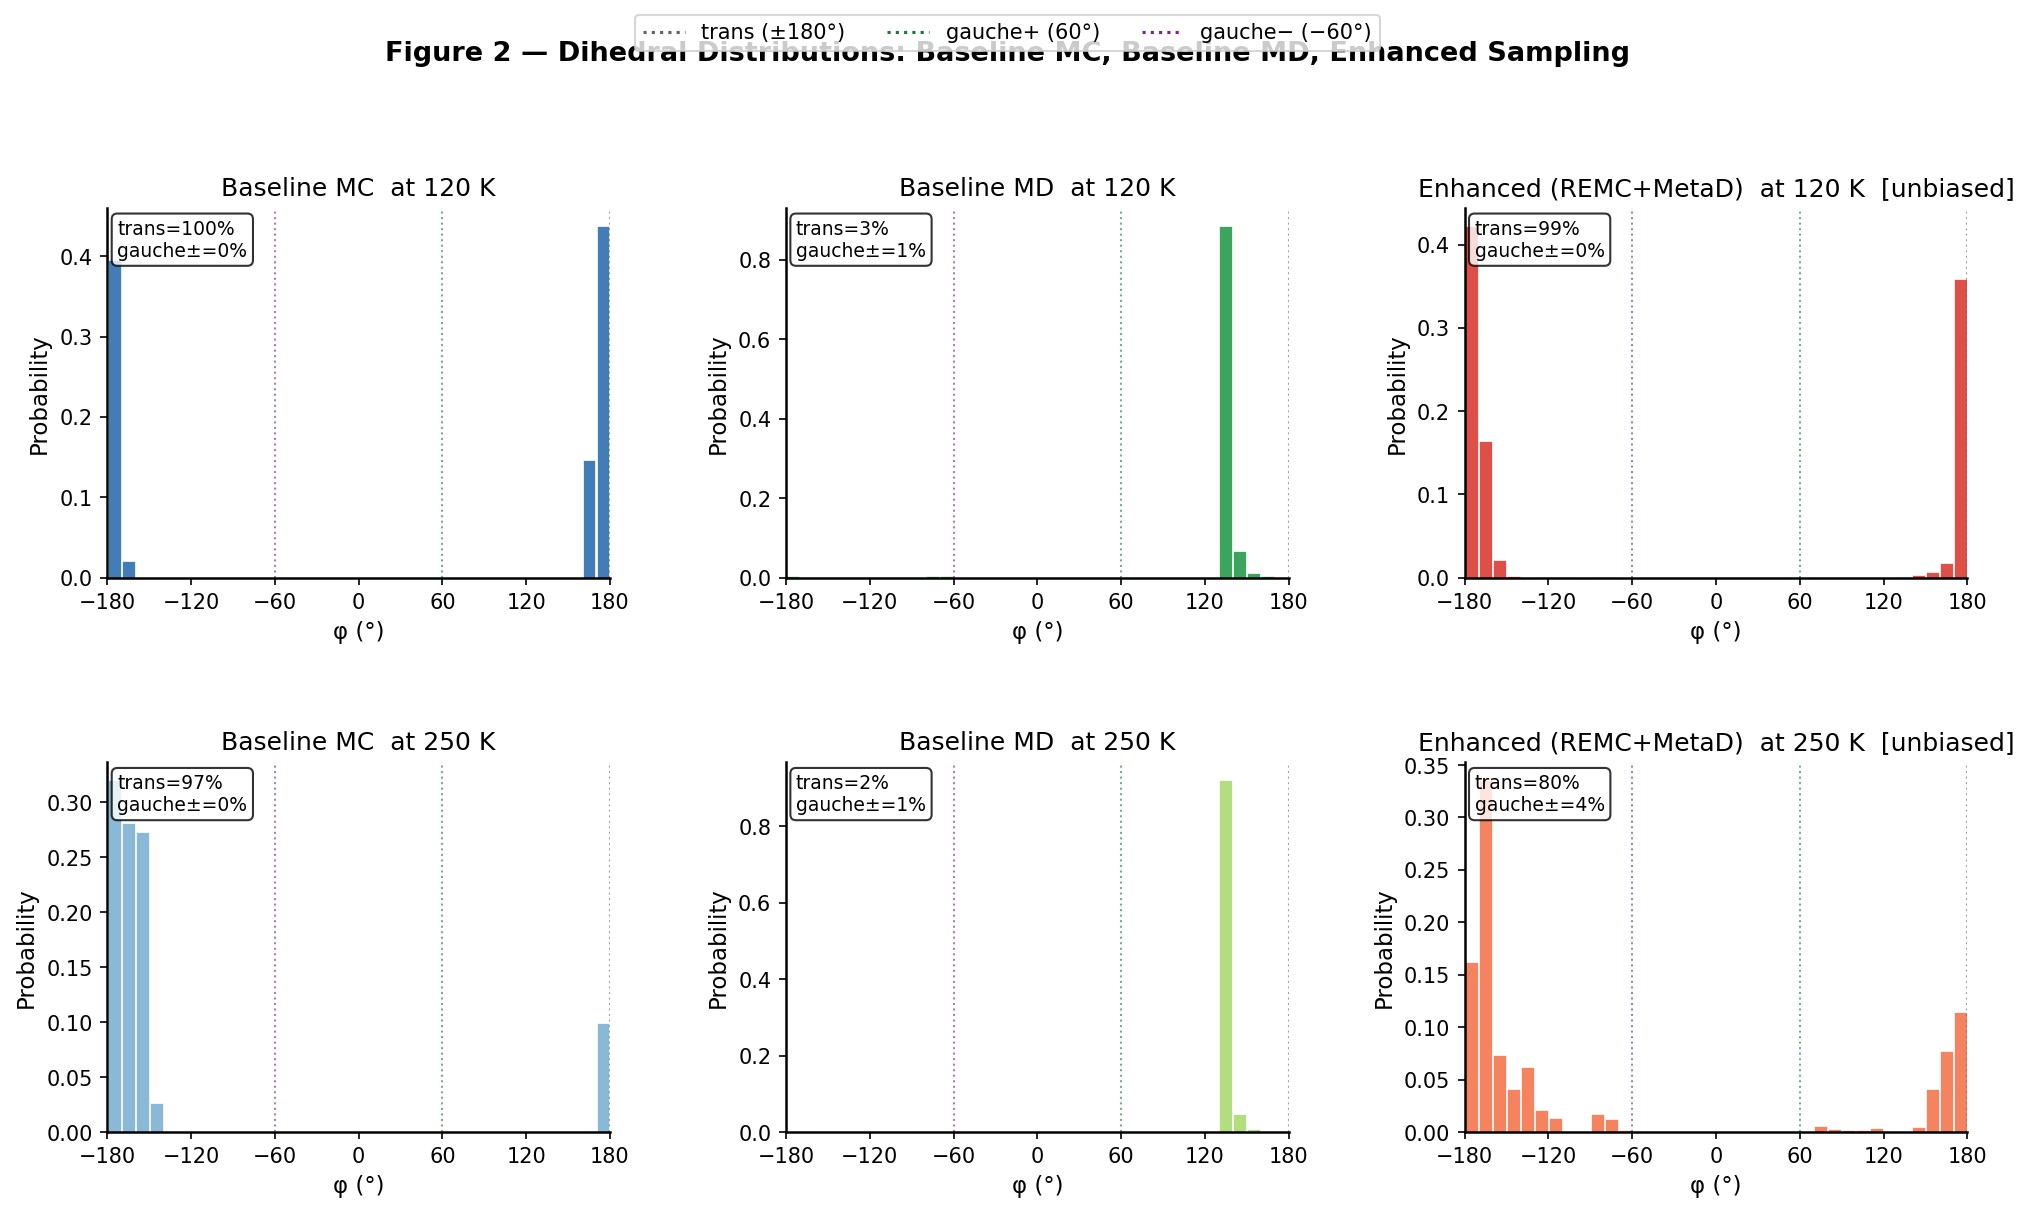

Saved: fig2_dihedral_histograms.png


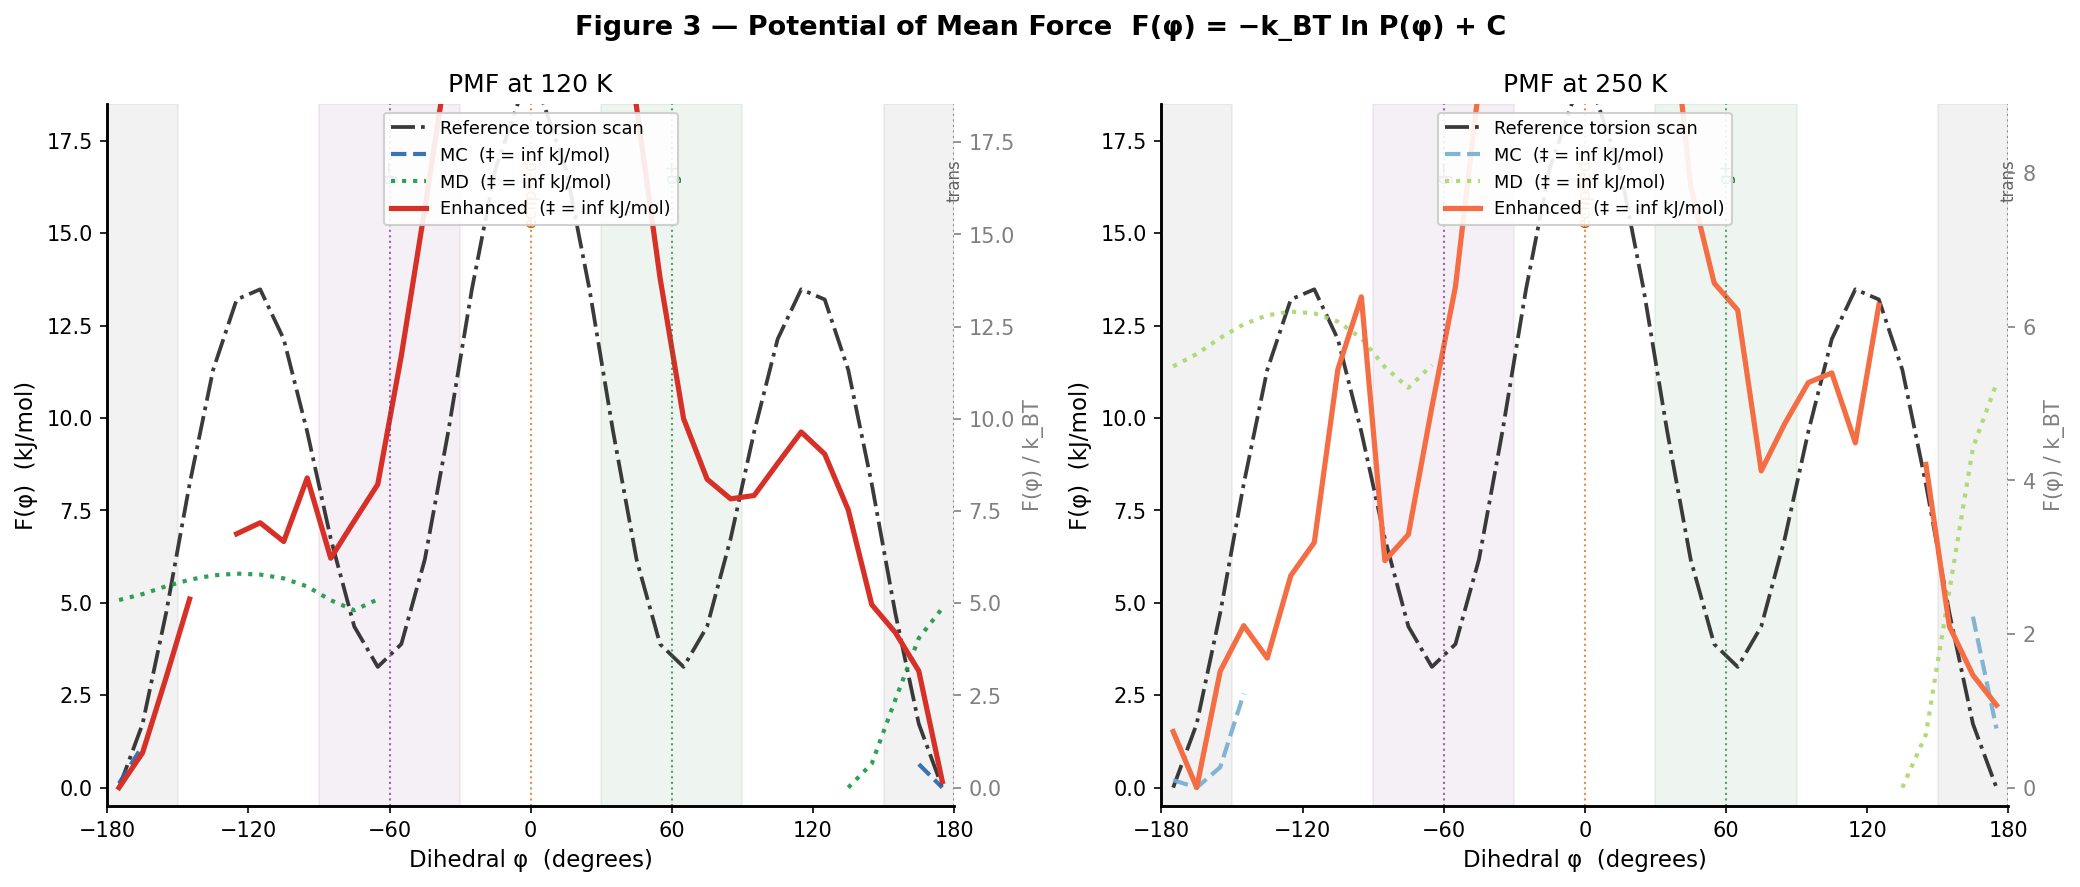

Saved: fig3_pmf_comparison.png


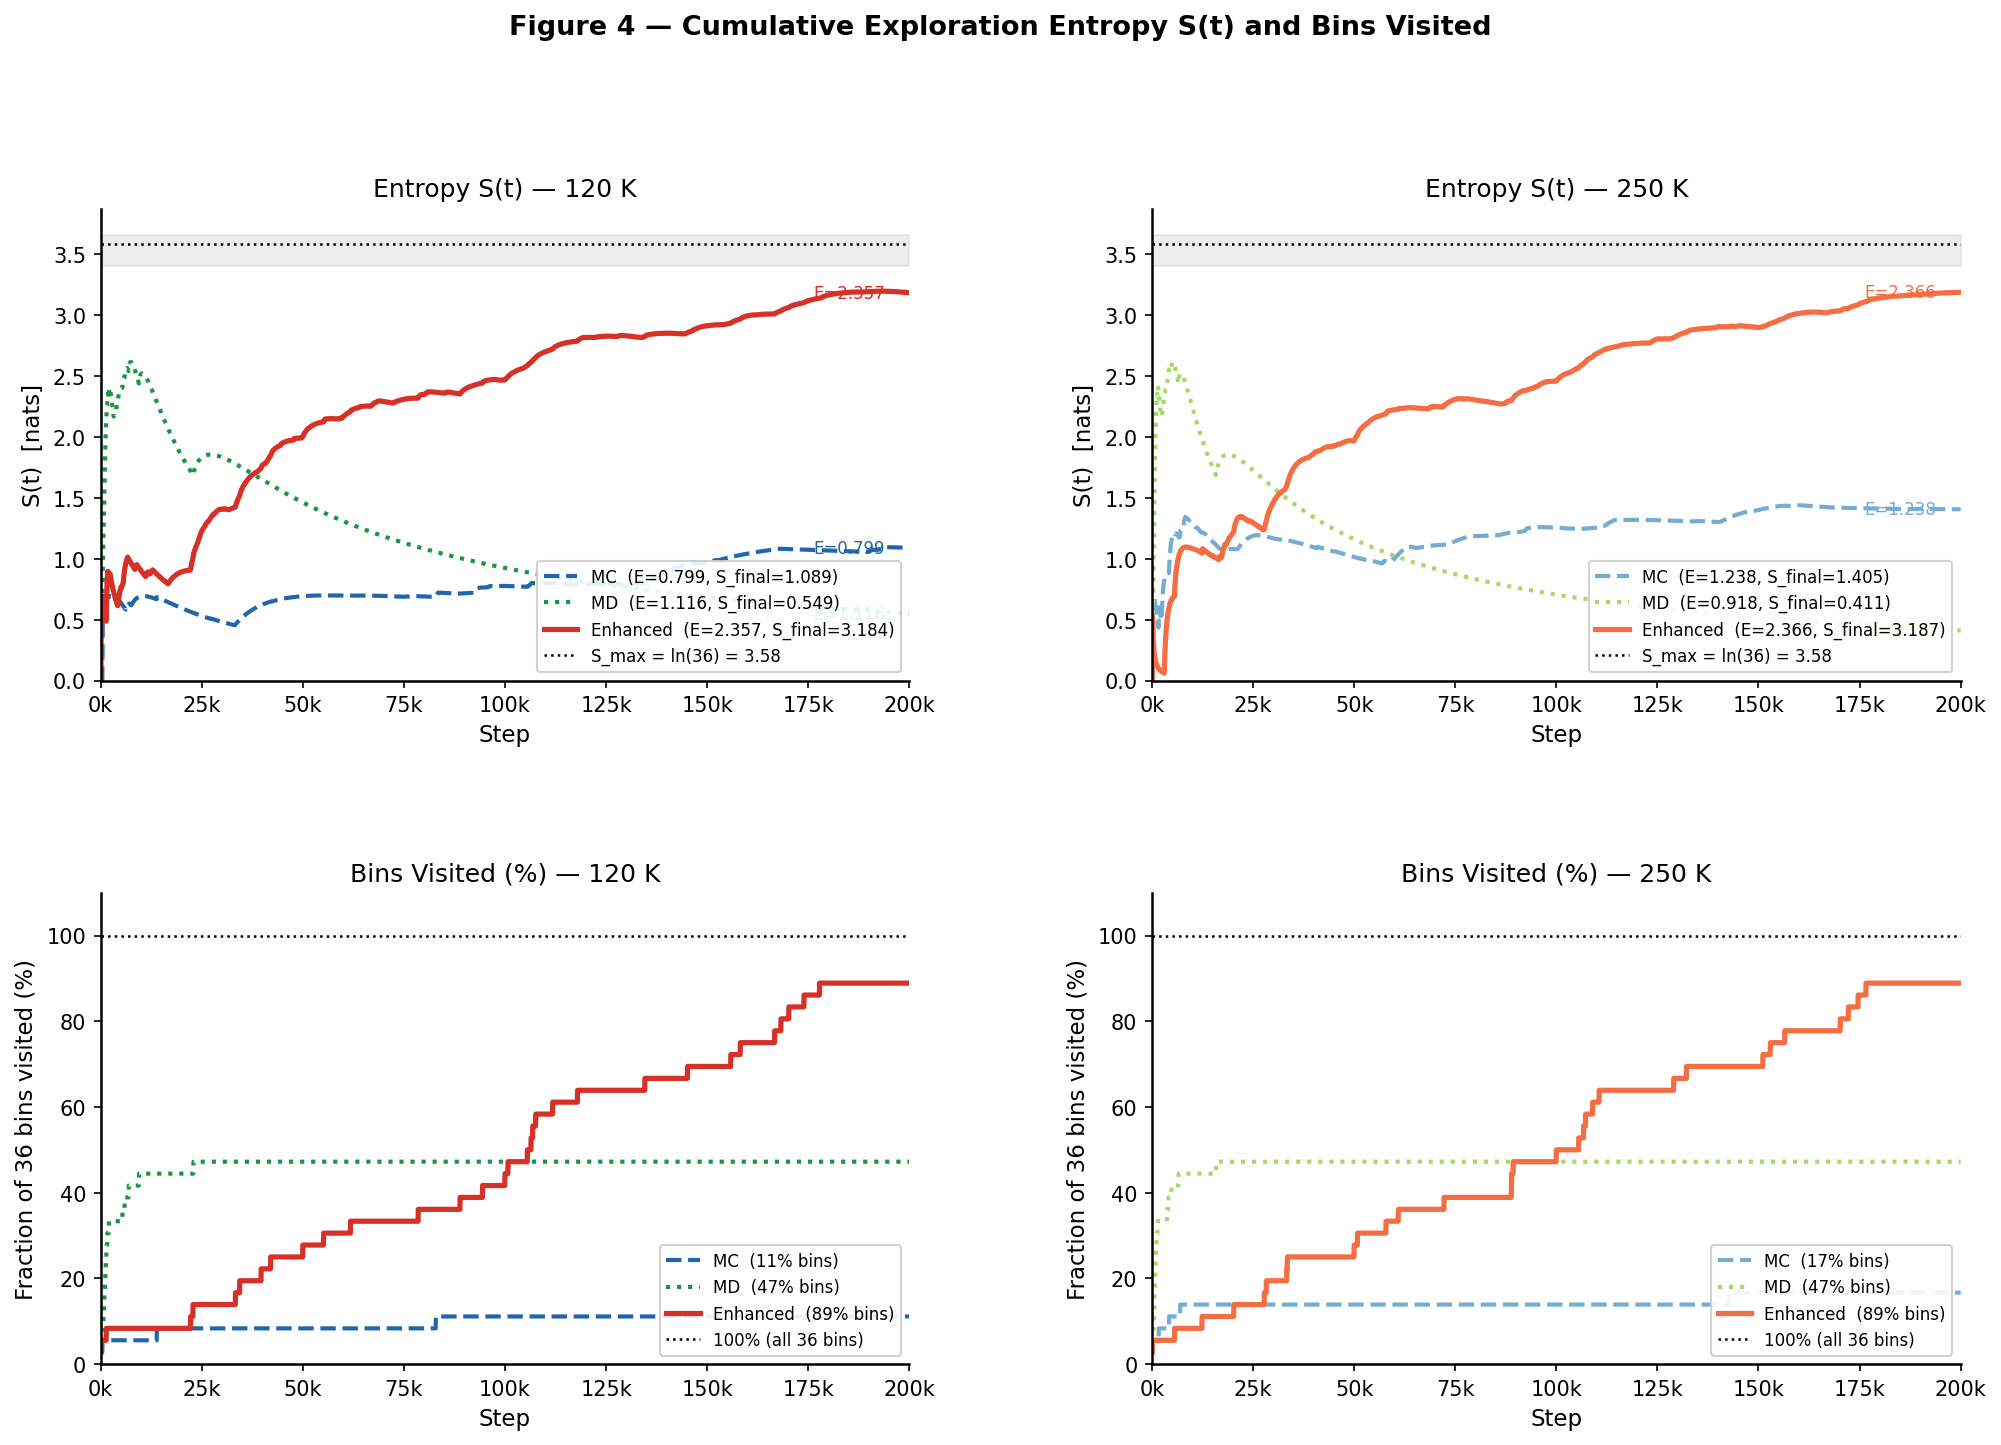

Saved: fig4_entropy_over_time.png


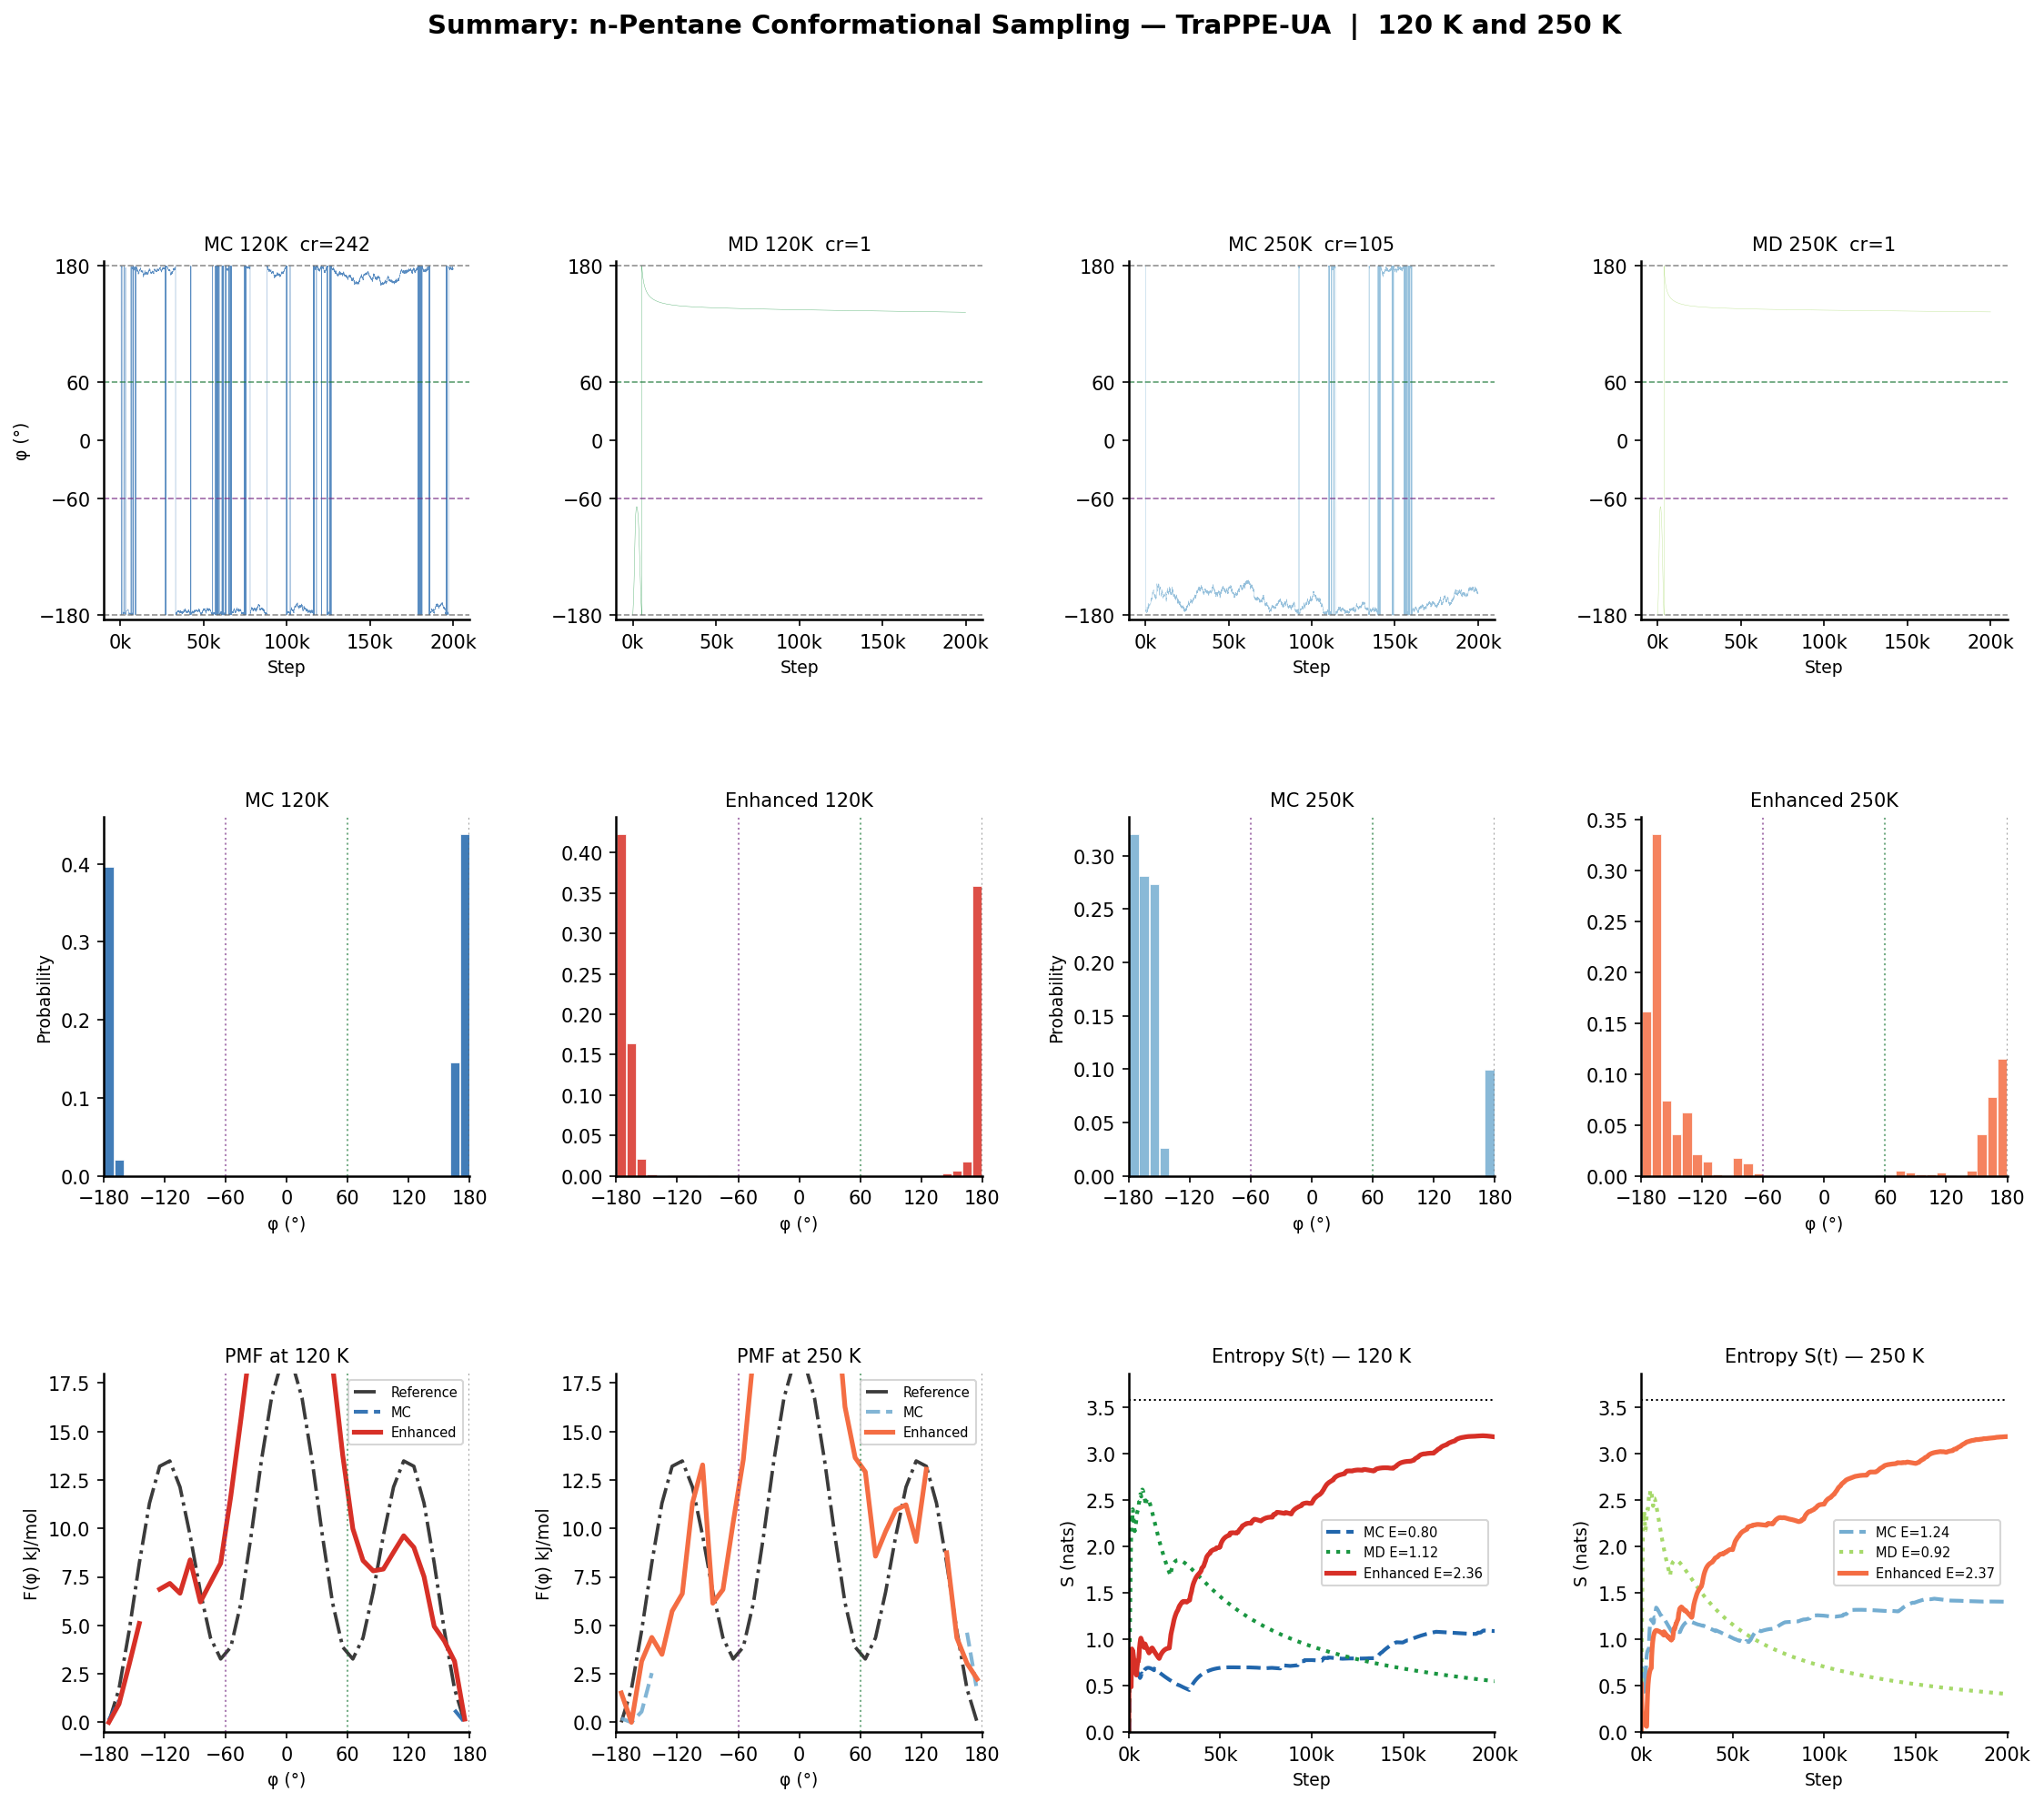

Saved: fig5_summary_panel.png

════════════════════════════════════════════════════
All figures saved:
  ✓  fig1_dihedral_timeseries.png
  ✓  fig2_dihedral_histograms.png
  ✓  fig3_pmf_comparison.png
  ✓  fig4_entropy_over_time.png
  ✓  fig5_summary_panel.png
════════════════════════════════════════════════════


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 12 — Final Comparison Plots (Publication Quality)
# ─────────────────────────────────────────────────────────────────────────────

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 12,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 9,
    'figure.dpi'        : 150,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.linewidth'    : 1.2,
    'xtick.direction'   : 'out',
    'ytick.direction'   : 'out',
})

# ── Color palette ─────────────────────────────────────────────────────────────
COLORS = {
    'MC_120'      : '#2166ac',   # blue
    'MD_120'      : '#1a9641',   # green
    'Enhanced_120': '#d73027',   # red
    'MC_250'      : '#74add1',   # light blue
    'MD_250'      : '#a6d96a',   # light green
    'Enhanced_250': '#f46d43',   # orange
    'Reference'   : '#252525',   # near-black
    'trans'       : '#636363',
    'gauche_p'    : '#1b7837',
    'gauche_m'    : '#762a83',
    'eclipsed'    : '#d95f02',
}

S_MAX = np.log(36)   # 3.584 nats
N_BINS     = 36
BIN_EDGES  = np.linspace(-180, 180, N_BINS + 1)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])
N_STEPS    = 200_000
STEPS      = np.arange(N_STEPS)

# Helper: format x-axis in thousands
def fmt_ksteps(ax):
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# Helper: draw conformation reference lines
def draw_ref_lines(ax, lw=1.0, alpha=0.6):
    for xv, c in [(180, COLORS['trans']), (-180, COLORS['trans']),
                   (60,  COLORS['gauche_p']), (-60, COLORS['gauche_m'])]:
        ax.axvline(xv, color=c, ls=':', lw=lw, alpha=alpha)



# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Dihedral Histograms: MC vs MD vs Enhanced at 120 K and 250 K
# ═════════════════════════════════════════════════════════════════════════════

fig2 = plt.figure(figsize=(16, 8))
gs2  = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.50, wspace=0.35)
fig2.suptitle(
    "Figure 2 — Dihedral Distributions: Baseline MC, Baseline MD, Enhanced Sampling",
    fontsize=13, fontweight='bold', y=1.02
)

def get_probs(dihedrals):
    counts, _ = np.histogram(dihedrals, bins=BIN_EDGES)
    return counts / counts.sum()

BAR_W = 360 / N_BINS - 0.8

for row, T in enumerate([120, 250]):
    mc_d  = results[f'MC_{T}']['dihedrals']
    md_d  = results[f'MD_{T}']['dihedrals']
    en_d  = enhanced_results[T]['cold_dihedrals']

    # Unbiased probs for enhanced
    _, _, en_probs = pmf_data[f'Enhanced_{T}']
    en_probs_plot  = np.where(np.isnan(en_probs), 0.0, en_probs)

    # ── (row,0): MC histogram ─────────────────────────────────────────────
    ax = fig2.add_subplot(gs2[row, 0])
    ax.bar(BIN_CENTERS, get_probs(mc_d), width=BAR_W,
           color=COLORS[f'MC_{T}'], alpha=0.85, edgecolor='white', lw=0.4)
    draw_ref_lines(ax)
    ax.set_title(f"Baseline MC  at {T} K")
    ax.set_xlabel("φ (°)"); ax.set_ylabel("Probability")
    ax.set_xlim(-180, 180); ax.set_xticks(np.arange(-180, 181, 60))

    # ── (row,1): MD histogram ─────────────────────────────────────────────
    ax = fig2.add_subplot(gs2[row, 1])
    ax.bar(BIN_CENTERS, get_probs(md_d), width=BAR_W,
           color=COLORS[f'MD_{T}'], alpha=0.85, edgecolor='white', lw=0.4)
    draw_ref_lines(ax)
    ax.set_title(f"Baseline MD  at {T} K")
    ax.set_xlabel("φ (°)"); ax.set_ylabel("Probability")
    ax.set_xlim(-180, 180); ax.set_xticks(np.arange(-180, 181, 60))

    # ── (row,2): Enhanced histogram (unbiased) ────────────────────────────
    ax = fig2.add_subplot(gs2[row, 2])
    ax.bar(BIN_CENTERS, en_probs_plot, width=BAR_W,
           color=COLORS[f'Enhanced_{T}'], alpha=0.85, edgecolor='white', lw=0.4)
    draw_ref_lines(ax)
    ax.set_title(f"Enhanced (REMC+MetaD)  at {T} K  [unbiased]")
    ax.set_xlabel("φ (°)"); ax.set_ylabel("Probability")
    ax.set_xlim(-180, 180); ax.set_xticks(np.arange(-180, 181, 60))

    # Annotate trans / gauche fractions on each panel
    for col_idx, (d_vals, method_key) in enumerate([
            (mc_d, f'MC_{T}'), (md_d, f'MD_{T}'), (None, f'Enhanced_{T}')]):
        ax_ann = fig2.axes[row * 3 + col_idx]
        if d_vals is not None:
            p_trans  = np.mean(np.abs(d_vals) > 150) * 100
            p_g      = np.mean((np.abs(d_vals) > 30) & (np.abs(d_vals) < 90)) * 100
        else:
            p_trans = np.sum(en_probs_plot[np.abs(BIN_CENTERS) > 150]) * 100
            p_g     = np.sum(en_probs_plot[(np.abs(BIN_CENTERS) > 30) &
                                           (np.abs(BIN_CENTERS) < 90)]) * 100
        ax_ann.text(0.02, 0.97,
                    f"trans={p_trans:.0f}%\ngauche±={p_g:.0f}%",
                    transform=ax_ann.transAxes,
                    va='top', ha='left', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

# Shared legend
legend_handles = [
    Line2D([0],[0], color=COLORS['trans'],   ls=':', lw=1.5, label='trans (±180°)'),
    Line2D([0],[0], color=COLORS['gauche_p'],ls=':', lw=1.5, label='gauche+ (60°)'),
    Line2D([0],[0], color=COLORS['gauche_m'],ls=':', lw=1.5, label='gauche− (−60°)'),
]
fig2.legend(handles=legend_handles, loc='upper center',
            ncol=3, bbox_to_anchor=(0.5, 1.05), fontsize=10)

plt.savefig("fig2_dihedral_histograms.png", dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig2_dihedral_histograms.png")


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — PMF Curves: Baseline vs Enhanced at 120 K and 250 K
# ═════════════════════════════════════════════════════════════════════════════

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle(
    "Figure 3 — Potential of Mean Force  F(φ) = −k_BT ln P(φ) + C",
    fontsize=13, fontweight='bold'
)

LINE_STYLES = {
    'Reference' : dict(color=COLORS['Reference'], ls='-.', lw=1.8, alpha=0.9),
    'MC'        : dict(color=COLORS['MC_120'],    ls='--', lw=2.0, alpha=0.9),
    'MD'        : dict(color=COLORS['MD_120'],    ls=':',  lw=2.0, alpha=0.9),
    'Enhanced'  : dict(color=COLORS['Enhanced_120'], ls='-', lw=2.5, alpha=1.0),
}
LINE_STYLES_250 = {
    'Reference' : dict(color=COLORS['Reference'], ls='-.', lw=1.8, alpha=0.9),
    'MC'        : dict(color=COLORS['MC_250'],    ls='--', lw=2.0, alpha=0.9),
    'MD'        : dict(color=COLORS['MD_250'],    ls=':',  lw=2.0, alpha=0.9),
    'Enhanced'  : dict(color=COLORS['Enhanced_250'], ls='-', lw=2.5, alpha=1.0),
}
ALL_STYLES = {120: LINE_STYLES, 250: LINE_STYLES_250}

for col, T in enumerate([120, 250]):
    ax  = axes3[col]
    sty = ALL_STYLES[T]

    for prefix in ['Reference', 'MC', 'MD', 'Enhanced']:
        bc, pmf, _ = pmf_data[f'{prefix}_{T}']
        s  = sty[prefix]

        # Build label with barrier height annotation
        if prefix != 'Reference':
            b, g = barrier_heights(bc, pmf)
            lbl  = f"{prefix}  (‡ = {b:.2f} kJ/mol)"
        else:
            lbl = f"Reference torsion scan"

        ax.plot(bc, pmf, label=lbl, **s)

    # Shade trans well
    ax.axvspan(150, 180,  color=COLORS['trans'], alpha=0.08)
    ax.axvspan(-180, -150, color=COLORS['trans'], alpha=0.08)
    # Shade gauche wells
    ax.axvspan( 30,  90, color=COLORS['gauche_p'], alpha=0.07)
    ax.axvspan(-90, -30, color=COLORS['gauche_m'], alpha=0.07)

    # Mark key conformations
    for xv, lbl_v, c in [(180,'trans', COLORS['trans']),
                          (60, 'g+',   COLORS['gauche_p']),
                          (-60,'g−',   COLORS['gauche_m']),
                          (0,  'eclipsed', COLORS['eclipsed'])]:
        ax.axvline(xv, color=c, ls=':', lw=1.0, alpha=0.7)
        ax.text(xv, 17.0, lbl_v, ha='center', va='top',
                fontsize=8, color=c, rotation=90)

    ax.set_title(f"PMF at {T} K", fontsize=12)
    ax.set_xlabel("Dihedral φ  (degrees)")
    ax.set_ylabel("F(φ)  (kJ/mol)")
    ax.set_xlim(-180, 180)
    ax.set_ylim(-0.5, 18.5)
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.legend(loc='upper center', fontsize=8.5, framealpha=0.9)

    # Second y-axis: normalised F / kBT
    ax2 = ax.twinx()
    ylim = ax.get_ylim()
    ax2.set_ylim(ylim[0] / (kB_kJ * T), ylim[1] / (kB_kJ * T))
    ax2.set_ylabel("F(φ) / k_BT", fontsize=10, color='gray')
    ax2.tick_params(axis='y', colors='gray')
    ax2.spines['right'].set_edgecolor('gray')

plt.tight_layout()
plt.savefig("fig3_pmf_comparison.png", dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig3_pmf_comparison.png")


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Entropy Over Time: All Methods, Both Temperatures
# ═════════════════════════════════════════════════════════════════════════════

fig4 = plt.figure(figsize=(16, 10))
gs4  = gridspec.GridSpec(2, 2, figure=fig4, hspace=0.45, wspace=0.30)
fig4.suptitle(
    "Figure 4 — Cumulative Exploration Entropy S(t) and Bins Visited",
    fontsize=13, fontweight='bold', y=1.01
)

ENTROPY_STYLES = {
    120: {
        'MC'      : dict(color=COLORS['MC_120'],       ls='--', lw=2.0),
        'MD'      : dict(color=COLORS['MD_120'],       ls=':',  lw=2.0),
        'Enhanced': dict(color=COLORS['Enhanced_120'], ls='-',  lw=2.5),
    },
    250: {
        'MC'      : dict(color=COLORS['MC_250'],       ls='--', lw=2.0),
        'MD'      : dict(color=COLORS['MD_250'],       ls=':',  lw=2.0),
        'Enhanced': dict(color=COLORS['Enhanced_250'], ls='-',  lw=2.5),
    },
}

for col, T in enumerate([120, 250]):
    sty = ENTROPY_STYLES[T]

    # ── (row=0): Entropy S(t) ─────────────────────────────────────────────
    ax_s = fig4.add_subplot(gs4[0, col])
    ax_b = fig4.add_subplot(gs4[1, col])

    for prefix in ['MC', 'MD', 'Enhanced']:
        lbl_key = f'{prefix}_{T}K'
        m       = metrics[lbl_key]
        E_val   = m['E']
        S_final = m['S_final']
        chk     = m['checkpoints']
        S_crv   = m['S_curve']
        frac    = m['frac_visited']

        label_s = f"{prefix}  (E={E_val:.3f}, S_final={S_final:.3f})"
        label_b = f"{prefix}  ({frac[-1]*100:.0f}% bins)"

        ax_s.plot(chk, S_crv,  label=label_s, **sty[prefix])
        ax_b.plot(chk, frac * 100, label=label_b, **sty[prefix])

    # Entropy panel formatting
    ax_s.axhline(S_MAX, color='black', ls=':', lw=1.2,
                 label=f'S_max = ln(36) = {S_MAX:.2f}')
    ax_s.fill_between([0, N_STEPS], [S_MAX * 0.95, S_MAX * 0.95],
                      [S_MAX * 1.02, S_MAX * 1.02],
                      color='lightgray', alpha=0.4, zorder=0)
    ax_s.set_title(f"Entropy S(t) — {T} K")
    ax_s.set_xlabel("Step"); ax_s.set_ylabel("S(t)  [nats]")
    ax_s.set_ylim(0, S_MAX * 1.08)
    ax_s.set_xlim(0, N_STEPS)
    fmt_ksteps(ax_s)
    ax_s.legend(loc='lower right', fontsize=8, framealpha=0.9)

    # Bins visited panel formatting
    ax_b.axhline(100, color='black', ls=':', lw=1.2, label='100% (all 36 bins)')
    ax_b.set_title(f"Bins Visited (%) — {T} K")
    ax_b.set_xlabel("Step"); ax_b.set_ylabel("Fraction of 36 bins visited (%)")
    ax_b.set_ylim(0, 110)
    ax_b.set_xlim(0, N_STEPS)
    fmt_ksteps(ax_b)
    ax_b.legend(loc='lower right', fontsize=8, framealpha=0.9)

    # Annotate early exploration score on entropy panel
    for i, prefix in enumerate(['MC', 'MD', 'Enhanced']):
        m = metrics[f'{prefix}_{T}K']
        ax_s.annotate(
            f"E={m['E']:.3f}",
            xy=(N_STEPS * 0.97, m['S_curve'][-1]),
            fontsize=8,
            color=sty[prefix]['color'],
            ha='right', va='center',
        )

plt.savefig("fig4_entropy_over_time.png", dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig4_entropy_over_time.png")


### Final summary tables and heatmaps
Builds summary tables, computes improvement factors, and plots performance heatmaps and bar charts.


════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  FINAL SUMMARY TABLE — n-Pentane TraPPE-UA  |  200,000 Steps
════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Method                  T(K) │  S_final  S_norm   Early E │ Bins/36  Cross90  Cross120 │   Acc%  Trans%    G+%    G-% │     PMF‡
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Baseline MC              120 │   1.0891  0.3039    0.7991 │     4/36      242       242 │   14.2   100.0    0.0    0.0 │      inf
Baseline MD              120 │   0.5489  0.1532    1.1159 │    17/36        1         1 │    N/A     2.8    0.0    1.5 │      inf
Enhanced+(Umbrella+WHAM)   120 │   3.1839  0.8885    2.3568 │    32/36       20        20 │    2.4    25.3   30.1   31.9 │      inf
─────────────────────────────────────────────────────────────────────────────

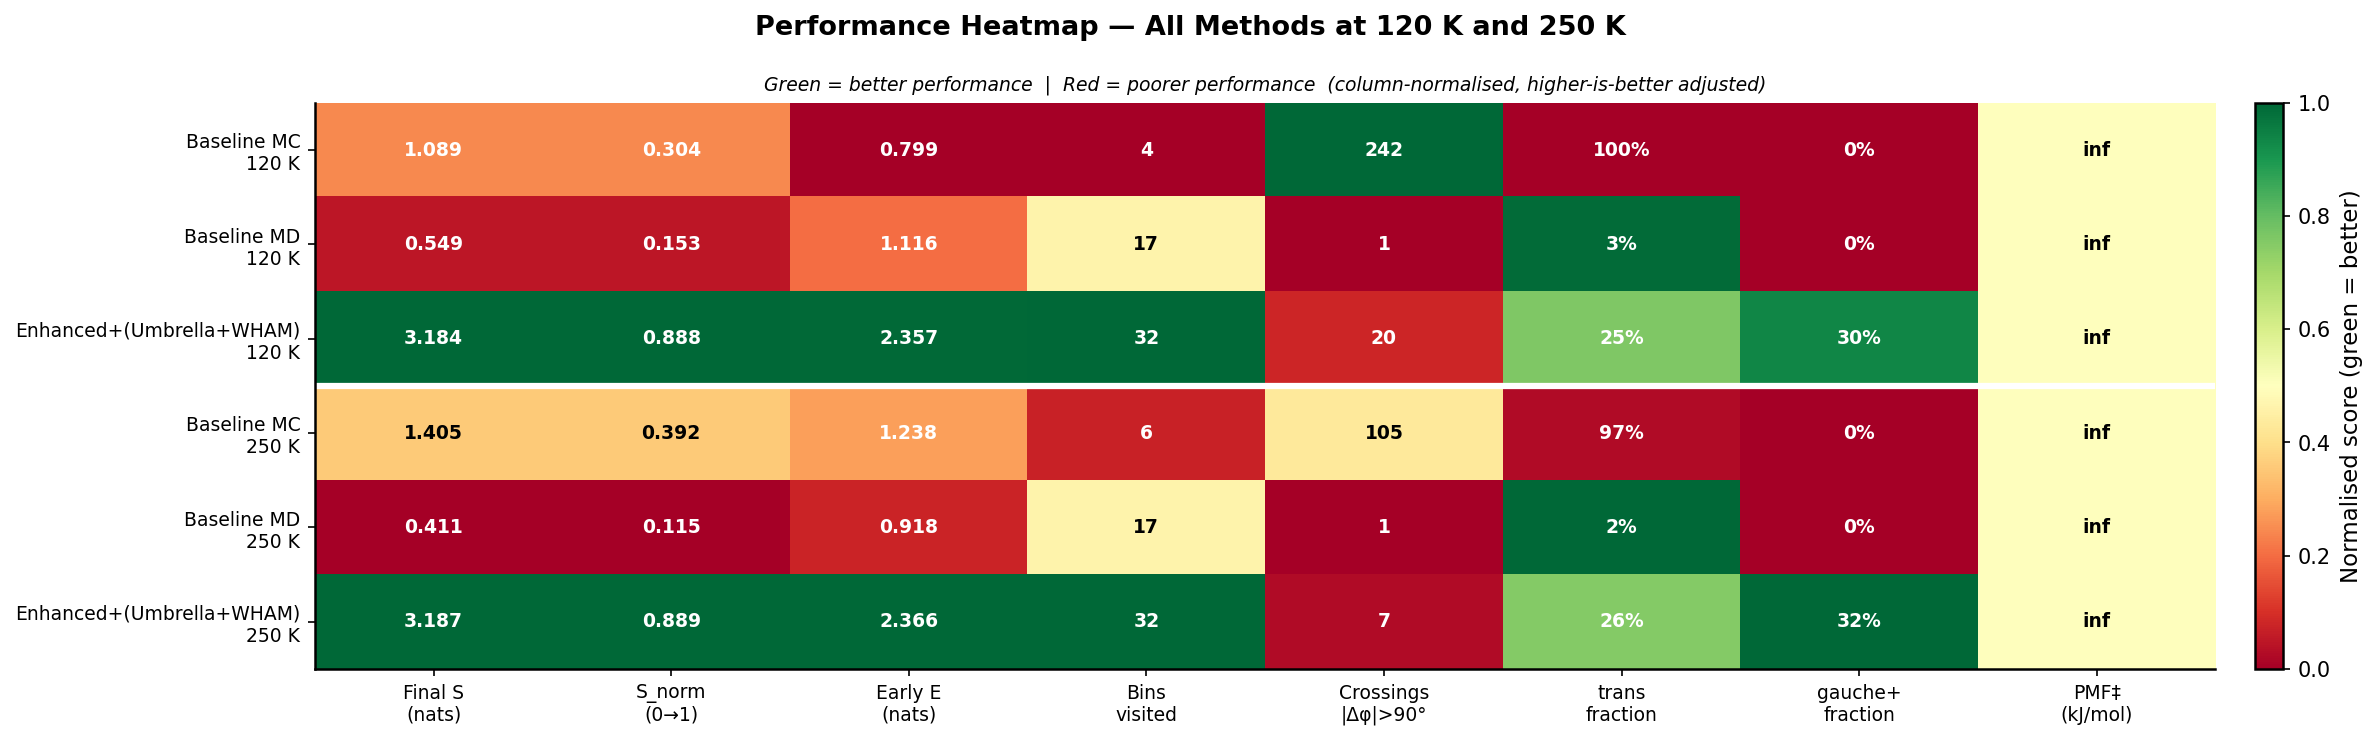

Saved: fig6_summary_heatmap.png


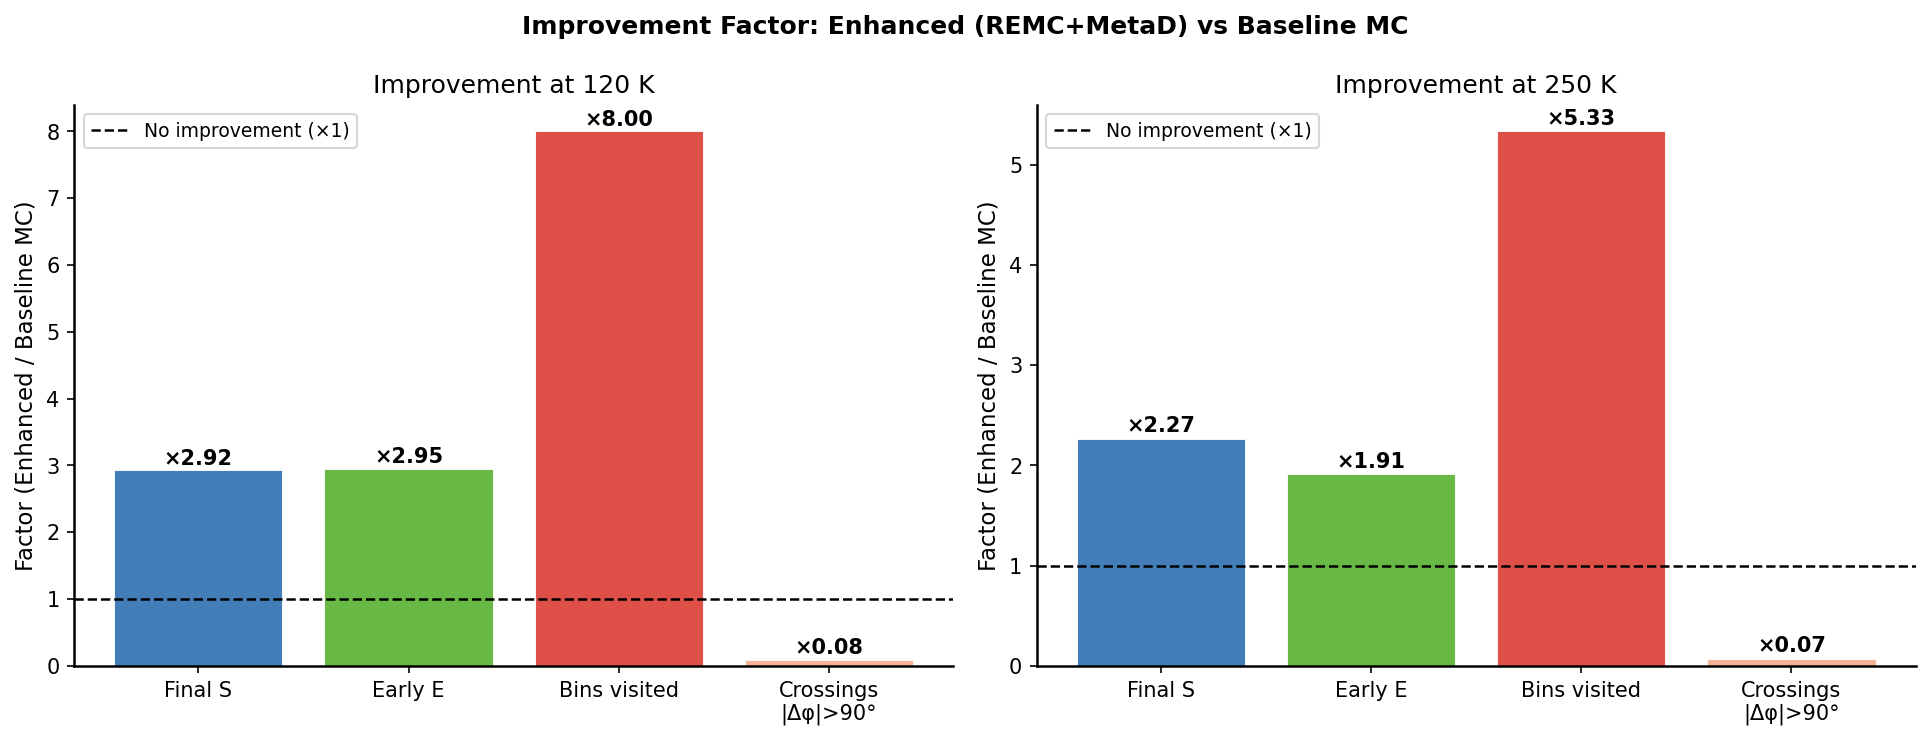

Saved: fig7_improvement_factors.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 13 — Final Summary Statistics Table
# ─────────────────────────────────────────────────────────────────────────────

# ── Collect all data into one flat registry ───────────────────────────────────

def _get_all_records():
    """
    Builds a list of dicts, one per simulation run, pulling from
    `results` (Cell 6/7), `enhanced_results` (Cell 9), and
    `metrics` (Cell 10).  Handles the different dict shapes cleanly.
    """
    records = []

    for T in [120, 250]:

        # ── Baseline MC ───────────────────────────────────────────────────
        mc = results[f'MC_{T}']
        d  = mc['dihedrals']
        m  = metrics[f'MC_{T}K']
        records.append(dict(
            method      = 'Baseline MC',
            T           = T,
            dihedrals   = d,
            acceptance  = mc.get('acceptance', float('nan')),
            S_final     = m['S_final'],
            S_norm      = m['S_norm'],
            E_score     = m['E'],
            S_curve     = m['S_curve'],
            checkpoints = m['checkpoints'],
            frac_bins   = m['frac_visited'],
        ))

        # ── Baseline MD ───────────────────────────────────────────────────
        md = results[f'MD_{T}']
        d  = md['dihedrals']
        m  = metrics[f'MD_{T}K']
        records.append(dict(
            method      = 'Baseline MD',
            T           = T,
            dihedrals   = d,
            acceptance  = float('nan'),    # MD has no acceptance rate
            S_final     = m['S_final'],
            S_norm      = m['S_norm'],
            E_score     = m['E'],
            S_curve     = m['S_curve'],
            checkpoints = m['checkpoints'],
            frac_bins   = m['frac_visited'],
        ))

        # ── Enhanced (REMC + WTMetaD) ─────────────────────────────────────
        er = enhanced_results[T]
        d  = er['cold_dihedrals']
        m  = metrics[f'Enhanced_{T}K']
        records.append(dict(
            method      = 'Enhanced\n(Umbrella+WHAM)',
            T           = T,
            dihedrals   = d,
            acceptance  = er['acceptance'],   # cold replica acceptance
            S_final     = m['S_final'],
            S_norm      = m['S_norm'],
            E_score     = m['E'],
            S_curve     = m['S_curve'],
            checkpoints = m['checkpoints'],
            frac_bins   = m['frac_visited'],
        ))

    return records


def _count_crossings(dihedrals, threshold=120.0):
    """Count steps with |Δφ| > threshold (trans↔gauche transitions)."""
    return int(np.sum(np.abs(np.diff(dihedrals)) > threshold))


def _conformation_fractions(dihedrals):
    d = np.asarray(dihedrals)
    return dict(
        trans   = float(np.mean(np.abs(d) > 150)),
        gauchep = float(np.mean((d >  30) & (d <  120))),
        gauchem = float(np.mean((d < -30) & (d > -120))),
    )


def _pmf_barrier(T, prefix):
    """Returns trans→gauche barrier height (kJ/mol) from stored PMF data."""
    try:
        bc, pmf, _ = pmf_data[f'{prefix}_{T}']
        b, _ = barrier_heights(bc, pmf)
        return b
    except Exception:
        return float('nan')


# ── Build full records ────────────────────────────────────────────────────────

records = _get_all_records()
S_MAX   = np.log(36)   # 3.584 nats

for rec in records:
    d   = rec['dihedrals']
    cf  = _conformation_fractions(d)
    rec['crossings_90']  = _count_crossings(d, threshold= 90.0)
    rec['crossings_120'] = _count_crossings(d, threshold=120.0)
    rec['frac_trans']    = cf['trans']
    rec['frac_gauchep']  = cf['gauchep']
    rec['frac_gauchem']  = cf['gauchem']
    rec['frac_other']    = 1 - cf['trans'] - cf['gauchep'] - cf['gauchem']
    rec['bins_visited']  = int(rec['frac_bins'][-1] * 36)

    prefix_map = {'Baseline MC': 'MC', 'Baseline MD': 'MD',
                  'Enhanced\n(Umbrella+WHAM)': 'Enhanced'}
    rec['pmf_barrier']   = _pmf_barrier(rec['T'], prefix_map[rec['method']])


# ── Console table ─────────────────────────────────────────────────────────────

SEP  = "─" * 112
SEP2 = "═" * 112

print(f"\n{SEP2}")
print("  FINAL SUMMARY TABLE — n-Pentane TraPPE-UA  |  200,000 Steps")
print(f"{SEP2}")

HEADER = (
    f"{'Method':<22} {'T(K)':>5} │ "
    f"{'S_final':>8} {'S_norm':>7} {'Early E':>9} │ "
    f"{'Bins/36':>7} {'Cross90':>8} {'Cross120':>9} │ "
    f"{'Acc%':>6} {'Trans%':>7} {'G+%':>6} {'G-%':>6} │ "
    f"{'PMF‡':>8}"
)
print(HEADER)
print(SEP)

prev_T = None
for rec in records:
    if prev_T is not None and rec['T'] != prev_T:
        print(SEP)
    prev_T = rec['T']

    method  = rec['method'].replace('\n', '+')
    acc_str = f"{rec['acceptance']*100:.1f}" if not np.isnan(rec['acceptance']) else "  N/A"
    barrier = f"{rec['pmf_barrier']:.2f}" if not np.isnan(rec['pmf_barrier']) else "  N/A"

    print(
        f"{method:<22} {rec['T']:>5} │ "
        f"{rec['S_final']:>8.4f} {rec['S_norm']:>7.4f} {rec['E_score']:>9.4f} │ "
        f"{rec['bins_visited']:>5}/36 {rec['crossings_90']:>8} {rec['crossings_120']:>9} │ "
        f"{acc_str:>6} {rec['frac_trans']*100:>7.1f} "
        f"{rec['frac_gauchep']*100:>6.1f} {rec['frac_gauchem']*100:>6.1f} │ "
        f"{barrier:>8}"
    )

print(f"{SEP2}")
print(f"  S_max = ln(36) = {S_MAX:.4f} nats   │   S_norm = S/S_max   "
      f"│   Cross = |Δφ| > threshold   │   PMF‡ = trans→gauche barrier (kJ/mol)")
print(f"{SEP2}")


# ── Improvement factors: Enhanced vs Baseline MC ─────────────────────────────

print(f"\n{'─'*60}")
print("  IMPROVEMENT FACTORS  (Enhanced / Baseline MC)")
print(f"{'─'*60}")
print(f"{'Metric':<30} {'120 K':>12} {'250 K':>12}")
print(f"{'─'*60}")

metrics_to_compare = [
    ('Final entropy S',      'S_final',     False),
    ('Early explore score E','E_score',     False),
    ('Bins visited',         'bins_visited',False),
    ('Crossings |Δφ|>90°',   'crossings_90',False),
]

for label, key, invert in metrics_to_compare:
    row = []
    for T in [120, 250]:
        base_recs = [r for r in records if r['T'] == T and r['method'] == 'Baseline MC']
        enha_recs = [r for r in records if r['T'] == T and 'Enhanced' in r['method']]
        if base_recs and enha_recs:
            base_val = base_recs[0][key]
            enha_val = enha_recs[0][key]
            if base_val > 0:
                factor = enha_val / base_val if not invert else base_val / enha_val
                row.append(f"{factor:>10.2f}×")
            else:
                row.append("   ∞ (zero baseline)")
        else:
            row.append("    N/A")
    print(f"  {label:<28} {row[0]:>12} {row[1]:>12}")

print(f"{'─'*60}")


# ── Figure: colour-coded summary heatmap ─────────────────────────────────────

PLOT_METRICS = [
    ('S_final',      'Final S\n(nats)',           True),    # True = higher is better
    ('S_norm',       'S_norm\n(0→1)',              True),
    ('E_score',      'Early E\n(nats)',            True),
    ('bins_visited', 'Bins\nvisited',              True),
    ('crossings_90', 'Crossings\n|Δφ|>90°',       True),
    ('frac_trans',   'trans\nfraction',            False),   # lower is better (means trapped)
    ('frac_gauchep', 'gauche+\nfraction',          True),
    ('pmf_barrier',  'PMF‡\n(kJ/mol)',             None),    # neutral (reference)
]

n_rows = len(records)
n_cols = len(PLOT_METRICS)

# Build matrix
mat   = np.full((n_rows, n_cols), np.nan)
for r_idx, rec in enumerate(records):
    for c_idx, (key, _, _) in enumerate(PLOT_METRICS):
        mat[r_idx, c_idx] = rec.get(key, float('nan'))

# Row labels
row_labels = [f"{r['method'].replace(chr(10),'+')}\n{r['T']} K" for r in records]
col_labels = [lbl for _, lbl, _ in PLOT_METRICS]

fig6, ax6 = plt.subplots(figsize=(16, 5))
fig6.suptitle("Performance Heatmap — All Methods at 120 K and 250 K",
              fontsize=13, fontweight='bold')

# Normalise each column to [0,1] for colouring
mat_norm = np.full_like(mat, np.nan)
for c in range(n_cols):
    col  = mat[:, c]
    valid = ~np.isnan(col)
    if valid.sum() > 1:
        cmin, cmax = col[valid].min(), col[valid].max()
        if cmax > cmin:
            mat_norm[:, c] = (col - cmin) / (cmax - cmin)
        else:
            mat_norm[:, c] = 0.5

# Flip for "lower is better" columns
for c_idx, (_, _, higher_better) in enumerate(PLOT_METRICS):
    if higher_better is False:
        mat_norm[:, c_idx] = 1.0 - mat_norm[:, c_idx]

cmap = plt.cm.RdYlGn
im   = ax6.imshow(mat_norm, cmap=cmap, aspect='auto', vmin=0, vmax=1)

# Annotate cells with actual values
for r in range(n_rows):
    for c in range(n_cols):
        val = mat[r, c]
        if not np.isnan(val):
            if PLOT_METRICS[c][0] in ('bins_visited', 'crossings_90', 'crossings_120'):
                txt = f"{int(val)}"
            elif PLOT_METRICS[c][0].startswith('frac'):
                txt = f"{val*100:.0f}%"
            else:
                txt = f"{val:.3f}"
            brightness = mat_norm[r, c]
            txt_color  = 'black' if 0.35 < brightness < 0.75 else 'white'
            ax6.text(c, r, txt, ha='center', va='center',
                     fontsize=9, color=txt_color, fontweight='bold')

ax6.set_xticks(range(n_cols)); ax6.set_xticklabels(col_labels, fontsize=9)
ax6.set_yticks(range(n_rows)); ax6.set_yticklabels(row_labels, fontsize=9)

# Horizontal separator between 120 K and 250 K groups
ax6.axhline(2.5, color='white', lw=3)

plt.colorbar(im, ax=ax6, label='Normalised score (green = better)',
             fraction=0.02, pad=0.02)
ax6.set_title("Green = better performance  |  Red = poorer performance  "
              "(column-normalised, higher-is-better adjusted)",
              fontsize=9, style='italic')

plt.tight_layout()
plt.savefig("fig6_summary_heatmap.png", dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig6_summary_heatmap.png")